In [ ]:
# Libraries instalation
! pip3 install imbalanced-learn
! pip install mixed-naive-bayes
! pip install tensorflow_addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 4.6 MB/s eta 0:00:00


# Business understanding


-> Business Objectives:

The movement of customers between different telecommunication companies is a core part of the business.
Since retaining loyal customers is cheaper than finding new ones, companies find anticipating the customers that are more likely to leave a very important step into being above its competition.
This is important to know, to define specific marketing strategy towards a client that is going to leave.
It is important to assemble specific marketing strategies in order to avoid the exit of unsatisfied clients.


-> Business Success Criteria:

Reducing the exit of unsatisfied clients through specific marketing strategies.


-> What is the machine learning goal?

To obtain a model that predicts the majority of leaving customers, while reducing the efforts with marketing for satisfied customers, using the existing data.

-> Which are the success criteria?

High sensitivity in identifying dissatisfied customers, with the greatest possible precision.



# Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import sklearn.metrics as mtr
from sklearn.tree import plot_tree
from collections import Counter
from scipy import stats
from scipy.stats import randint
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from mixed_naive_bayes import MixedNB
from sklearn.metrics import make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC,SVC,NuSVC
from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, confusion_matrix,f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from keras.layers import Dense
from keras.models import Sequential
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.fixes import loguniform
import tensorflow_addons as tfa
import tensorflow.keras.backend as K

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


## Data Structure

In [ ]:
# Ingestion of the data

churn_df = pd.read_csv('churn_data.csv')

print("Data has",churn_df.shape[0],"rows and",churn_df.shape[1],"attributes")
print(churn_df.columns)


Data has 5000 rows and 18 attributes
Index(['churn', 'accountlength', 'internationalplan', 'voicemailplan',
       'numbervmailmessages', 'totaldayminutes', 'totaldaycalls',
       'totaldaycharge', 'totaleveminutes', 'totalevecalls', 'totalevecharge',
       'totalnightminutes', 'totalnightcalls', 'totalnightcharge',
       'totalintlminutes', 'totalintlcalls', 'totalintlcharge',
       'numbercustomerservicecalls'],
      dtype='object')


In [ ]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   churn                       5000 non-null   object 
 1   accountlength               4951 non-null   float64
 2   internationalplan           4950 non-null   object 
 3   voicemailplan               4950 non-null   object 
 4   numbervmailmessages         4950 non-null   float64
 5   totaldayminutes             4950 non-null   float64
 6   totaldaycalls               4950 non-null   float64
 7   totaldaycharge              4950 non-null   float64
 8   totaleveminutes             4950 non-null   float64
 9   totalevecalls               4950 non-null   float64
 10  totalevecharge              4950 non-null   float64
 11  totalnightminutes           4950 non-null   float64
 12  totalnightcalls             4950 non-null   float64
 13  totalnightcharge            4950 

In [ ]:
# Looking at the info for the churn_df we see 3 features that are objetcs, bellow is the description of these variables.
print(f" churn -> {churn_df['churn'].value_counts()}")
print(f" voicemailplan -> {churn_df['voicemailplan'].value_counts()}")
print(f" internationalplan -> {churn_df['internationalplan'].value_counts()}")

 churn -> No     4293
Yes     707
Name: churn, dtype: int64
 voicemailplan -> no     3638
yes    1312
Name: voicemailplan, dtype: int64
 internationalplan -> no     4481
yes     469
Name: internationalplan, dtype: int64


In [ ]:
churn_df.describe()

,accountlength,numbervmailmessages,totaldayminutes,totaldaycalls,totaldaycharge,totaleveminutes,totalevecalls,totalevecharge,totalnightminutes,totalnightcalls,totalnightcharge,totalintlminutes,totalintlcalls,totalintlcharge,numbercustomerservicecalls
count,4951.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000,4950.000000
mean,100.238295,7.763636,180.306625,100.038788,30.629386,200.679798,100.243838,17.048293,200.465697,99.932929,9.015240,10.259010,4.432525,2.772088,1.569091
std,39.718817,13.552928,53.926625,19.844529,9.148881,50.486434,19.837380,4.300503,50.498290,19.939450,2.276812,2.763712,2.448457,0.744552,1.305279
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.700000,87.000000,24.430000,166.425000,87.000000,14.130000,167.000000,87.000000,7.510000,8.500000,3.000000,2.300000,1.000000
50%,100.000000,0.000000,180.100000,100.000000,30.600000,201.000000,101.000000,17.090000,200.550000,100.000000,9.010000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,17.000000,216.200000,113.000000,36.720000,234.100000,114.000000,19.897500,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000
max,243.000000,52.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Columns description:

churn, internationalplan and voicemailplan are categorical datatypes where all the rest are numerical datatypes.

In [ ]:
# Two dataframes - CHURN=Yes
churn_yes_df = churn_df[churn_df['churn'] == 'Yes']
churn_yes_df.describe()

,accountlength,numbervmailmessages,totaldayminutes,totaldaycalls,totaldaycharge,totaleveminutes,totalevecalls,totalevecharge,totalnightminutes,totalnightcalls,totalnightcharge,totalintlminutes,totalintlcalls,totalintlcharge,numbercustomerservicecalls
count,700.000000,699.000000,697.000000,699.000000,702.000000,696.000000,703.000000,701.000000,703.000000,704.000000,703.000000,697.000000,698.000000,697.000000,698.000000
mean,102.002841,4.420601,207.406169,100.814020,35.211720,211.868103,99.847795,18.000071,205.871266,99.596591,9.275206,10.683644,4.157593,2.885196,2.272206
std,39.188821,11.222313,68.776311,20.791495,11.650465,51.616960,19.574415,4.382930,49.667286,19.987885,2.239386,2.781366,2.549556,0.752742,1.817451
min,1.000000,0.000000,0.000000,0.000000,0.000000,70.900000,48.000000,6.030000,47.400000,42.000000,2.130000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,0.000000,153.200000,88.000000,26.032500,176.200000,86.500000,14.950000,171.650000,85.000000,7.730000,8.800000,2.000000,2.400000,1.000000
50%,102.000000,0.000000,212.800000,101.000000,36.120000,211.200000,99.000000,17.960000,205.900000,100.000000,9.280000,10.600000,4.000000,2.860000,2.000000
75%,126.000000,0.000000,266.100000,114.500000,45.235000,249.300000,113.000000,21.190000,240.600000,114.000000,10.850000,12.700000,5.000000,3.460000,4.000000
max,225.000000,48.000000,351.500000,165.000000,59.760000,363.700000,168.000000,30.910000,381.600000,158.000000,17.170000,20.000000,20.000000,5.400000,9.000000


In [ ]:
# Two dataframes - CHURN=No

churn_no_df = churn_df[churn_df['churn'] == 'No']
churn_no_df.describe()

,accountlength,numbervmailmessages,totaldayminutes,totaldaycalls,totaldaycharge,totaleveminutes,totalevecalls,totalevecharge,totalnightminutes,totalnightcalls,totalnightcharge,totalintlminutes,totalintlcalls,totalintlcharge,numbercustomerservicecalls
count,4251.000000,4251.000000,4253.000000,4251.000000,4248.000000,4254.000000,4247.000000,4249.000000,4247.000000,4246.000000,4247.000000,4253.000000,4252.000000,4253.000000,4252.000000
mean,99.947732,8.313338,175.865434,99.911315,29.872136,198.849271,100.309395,16.891269,199.570921,99.988695,8.972209,10.189419,4.477658,2.753552,1.453669
std,39.802470,13.822732,49.703100,19.684079,8.431441,50.067749,19.882092,4.266917,50.584593,19.933219,2.280350,2.754900,2.428797,0.741647,1.160783
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.100000,87.000000,24.320000,164.500000,87.000000,13.970000,165.900000,87.000000,7.460000,8.500000,3.000000,2.300000,1.000000
50%,100.000000,0.000000,178.100000,100.000000,30.250000,199.500000,101.000000,16.960000,199.300000,100.000000,8.950000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,20.000000,210.700000,113.000000,35.800000,232.300000,114.000000,19.740000,233.500000,113.000000,10.500000,12.000000,6.000000,3.240000,2.000000
max,243.000000,52.000000,315.600000,163.000000,53.650000,361.800000,170.000000,30.750000,395.000000,175.000000,17.770000,19.700000,19.000000,5.320000,8.000000


## Outliers and statistical summaries

### Histograms

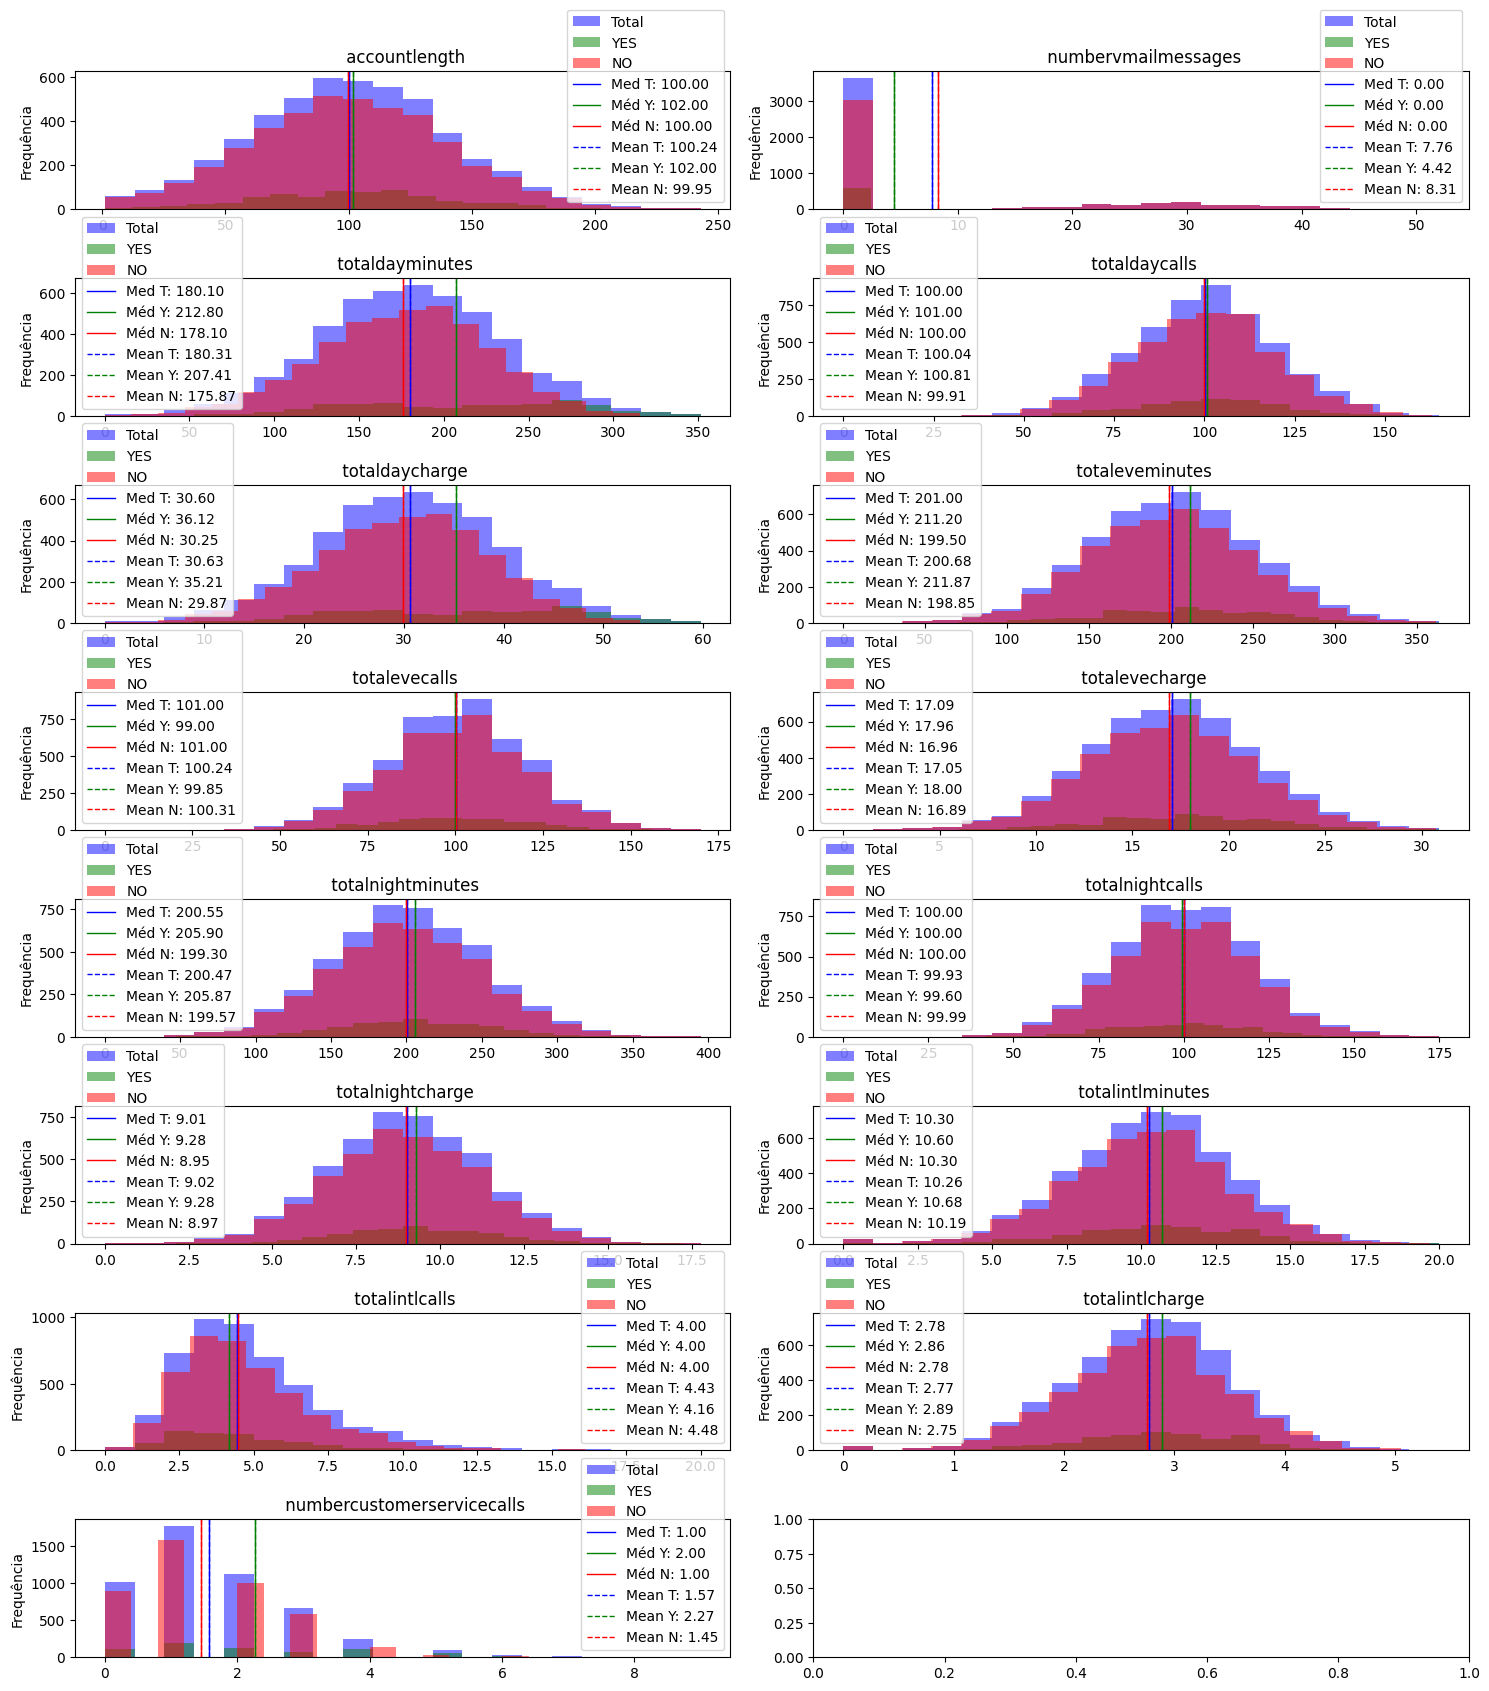

In [ ]:
# Cria uma figura com um grid 3x3 para os subplots
fig, axs = plt.subplots(8, 2, figsize=(15, 17))

# Variável para percorrer os subplots
axs = axs.flatten()

# Loop pelas colunas numéricas do DataFrame
numeric_columns = [coluna for coluna in churn_df.columns if np.issubdtype(churn_df[coluna].dtype, np.number)]

for i, coluna in enumerate(numeric_columns):

    # Plota o histograma da coluna atual no subplot correspondente com cores diferentes
    axs[i].hist(churn_df[coluna], bins=20, alpha=0.5, label='Total', color='blue')
    axs[i].hist(churn_yes_df[coluna], bins=20, alpha=0.5, label='YES', color='green')
    axs[i].hist(churn_no_df[coluna], bins=20, alpha=0.5, label='NO', color='red')

    # Calcula e adiciona média e mediana para cada conjunto
    mean_total = np.nanmean(churn_df[coluna])
    mean_yes = np.nanmean(churn_yes_df[coluna])
    mean_no = np.nanmean(churn_no_df[coluna])

    median_total = np.nanmedian(churn_df[coluna])
    median_yes = np.nanmedian(churn_yes_df[coluna])
    median_no = np.nanmedian(churn_no_df[coluna])

    axs[i].axvline(mean_total, color='blue', linestyle='-', linewidth=1, label=f'Med T: {median_total:.2f}')
    axs[i].axvline(mean_yes, color='green', linestyle='-', linewidth=1, label=f'Méd Y: {median_yes:.2f}')
    axs[i].axvline(mean_no, color='red', linestyle='-', linewidth=1, label=f'Méd N: {median_no:.2f}')



    axs[i].axvline(mean_total, color='blue', linestyle='dashed', linewidth=1, label=f'Mean T: {mean_total:.2f}')
    axs[i].axvline(mean_yes, color='green', linestyle='dashed', linewidth=1, label=f'Mean Y: {mean_yes:.2f}')
    axs[i].axvline(mean_no, color='red', linestyle='dashed', linewidth=1, label=f'Mean N: {mean_no:.2f}')


    # Define o título do histograma com o nome da coluna
    axs[i].set_title(f' {coluna}')

    # Adiciona legenda
    axs[i].legend()

    # Adiciona rótulos aos eixos
    #axs[i].set_xlabel(coluna)
    axs[i].set_ylabel('Frequência')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
# Mostra os subplots
plt.show()


The customers who leave the company usually have longer calls, especially throughout the day and evenings. From the plot above, because their mean and median values are similar, we can conclude that the number of calls does not distinguish between the two subsets.

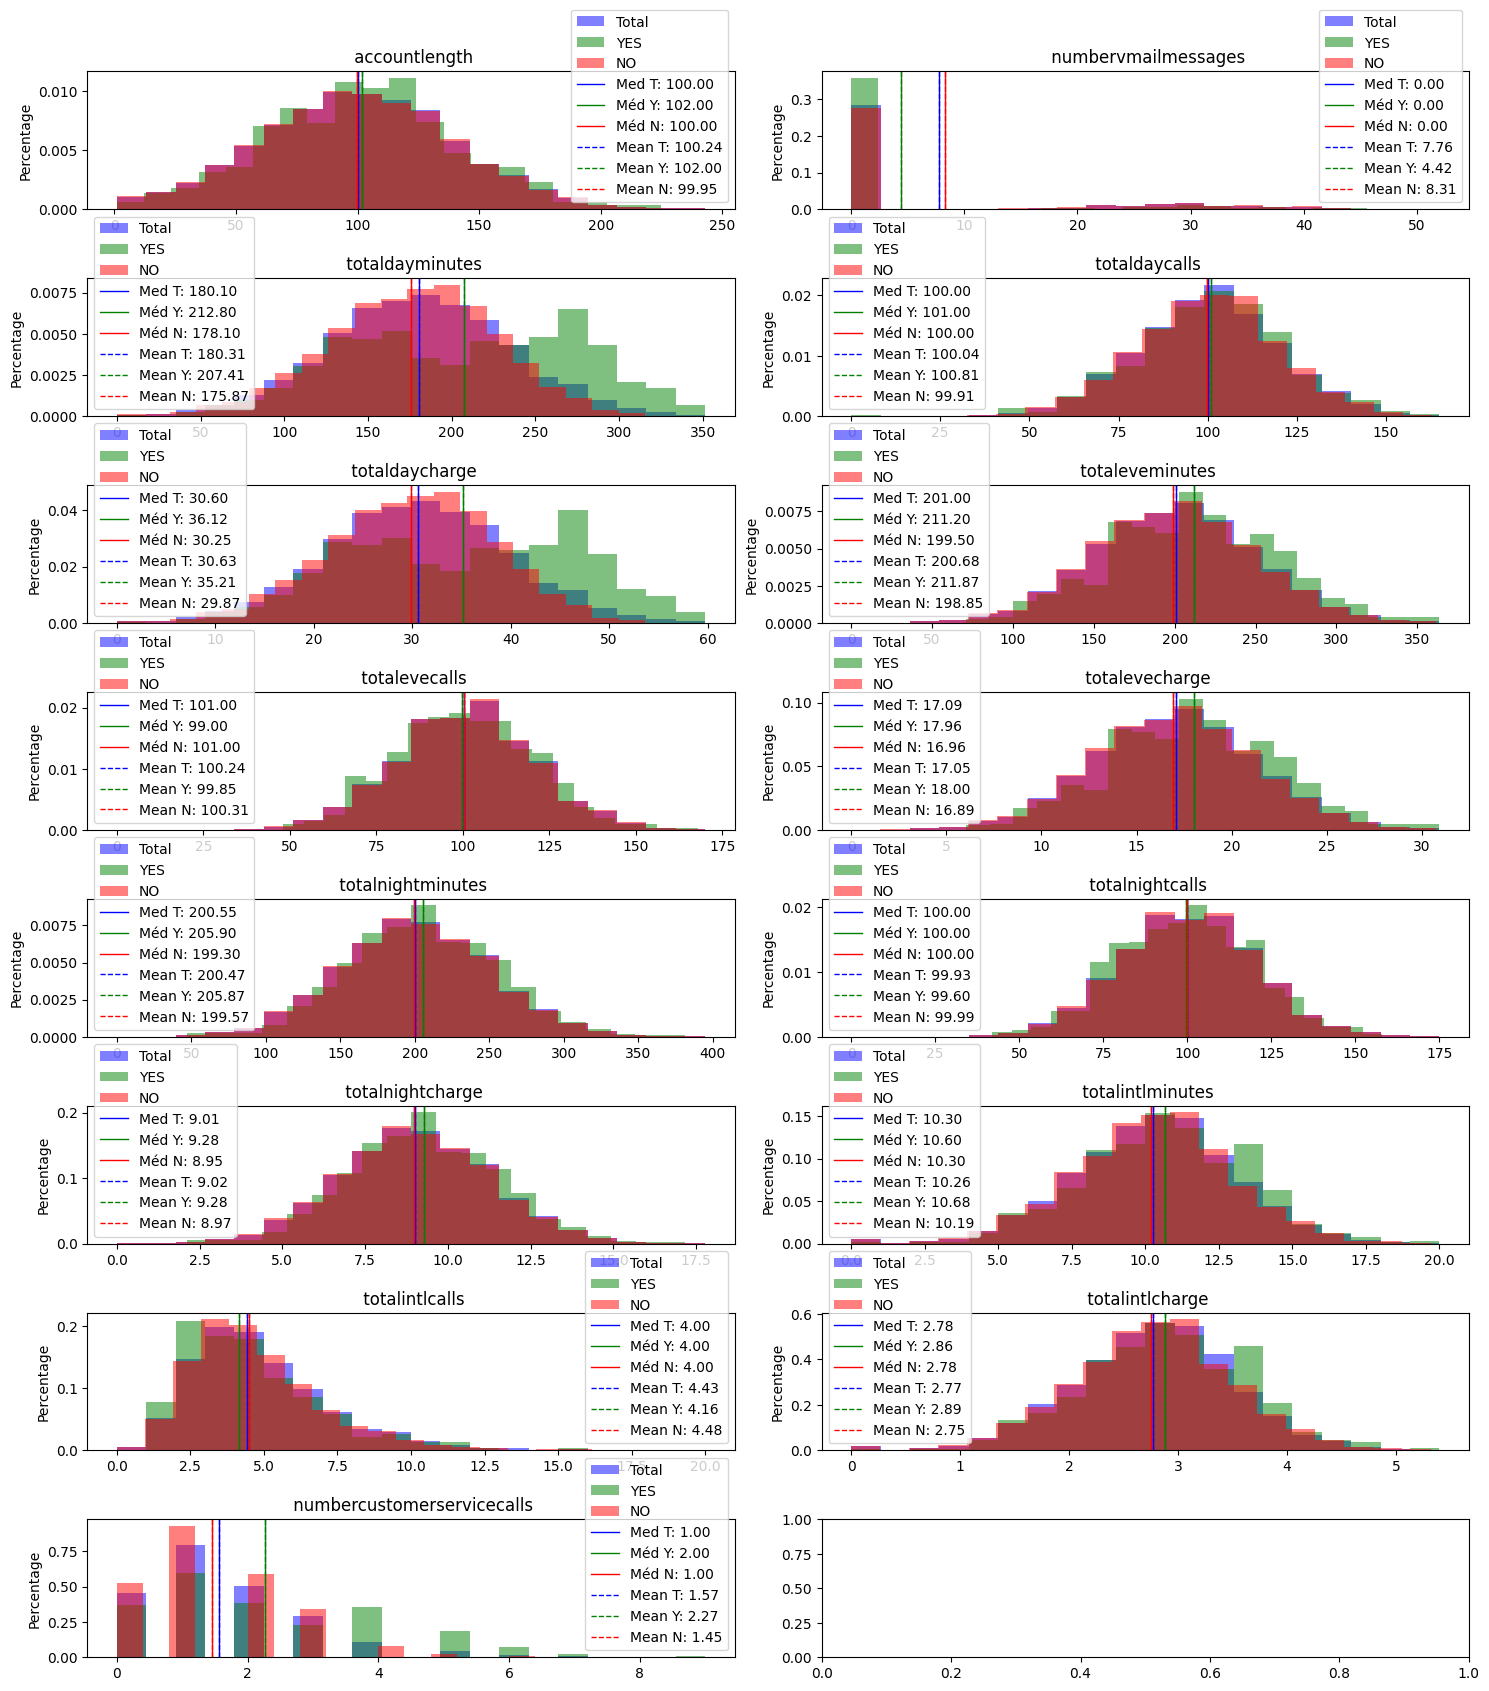

In [ ]:
# Cria uma figura com um grid 3x3 para os subplots
fig, axs = plt.subplots(8, 2, figsize=(15, 17))

# Variável para percorrer os subplots
axs = axs.flatten()

# Loop pelas colunas numéricas do DataFrame
numeric_columns = [coluna for coluna in churn_df.columns if np.issubdtype(churn_df[coluna].dtype, np.number)]

for i, coluna in enumerate(numeric_columns):

    # Plota o histograma da coluna atual no subplot correspondente com cores diferentes
    axs[i].hist(churn_df[coluna], bins=20, alpha=0.5, label='Total', color='blue', density=True)
    axs[i].hist(churn_yes_df[coluna], bins=20, alpha=0.5, label='YES', color='green',  density=True)
    axs[i].hist(churn_no_df[coluna], bins=20, alpha=0.5, label='NO', color='red', density=True)

    # Calcula e adiciona média e mediana para cada conjunto
    mean_total = np.nanmean(churn_df[coluna])
    mean_yes = np.nanmean(churn_yes_df[coluna])
    mean_no = np.nanmean(churn_no_df[coluna])

    median_total = np.nanmedian(churn_df[coluna])
    median_yes = np.nanmedian(churn_yes_df[coluna])
    median_no = np.nanmedian(churn_no_df[coluna])

    axs[i].axvline(mean_total, color='blue', linestyle='-', linewidth=1, label=f'Med T: {median_total:.2f}')
    axs[i].axvline(mean_yes, color='green', linestyle='-', linewidth=1, label=f'Méd Y: {median_yes:.2f}')
    axs[i].axvline(mean_no, color='red', linestyle='-', linewidth=1, label=f'Méd N: {median_no:.2f}')



    axs[i].axvline(mean_total, color='blue', linestyle='dashed', linewidth=1, label=f'Mean T: {mean_total:.2f}')
    axs[i].axvline(mean_yes, color='green', linestyle='dashed', linewidth=1, label=f'Mean Y: {mean_yes:.2f}')
    axs[i].axvline(mean_no, color='red', linestyle='dashed', linewidth=1, label=f'Mean N: {mean_no:.2f}')


    # Define o título do histograma com o nome da coluna
    axs[i].set_title(f' {coluna}')

    # Adiciona legenda
    axs[i].legend()

    # Adiciona rótulos aos eixos
    #axs[i].set_xlabel(coluna)
    axs[i].set_ylabel('Percentage')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
# Mostra os subplots
plt.show()

Because the data is unbalanced we are going to look for each class, normalised (using density = true),  instead of the frequency. We can see that the yes class calls much more to the costumer service than the no class. This plot alternative highlights the difference for the identified features('numbercustomersevicecalls').

### Boxplot

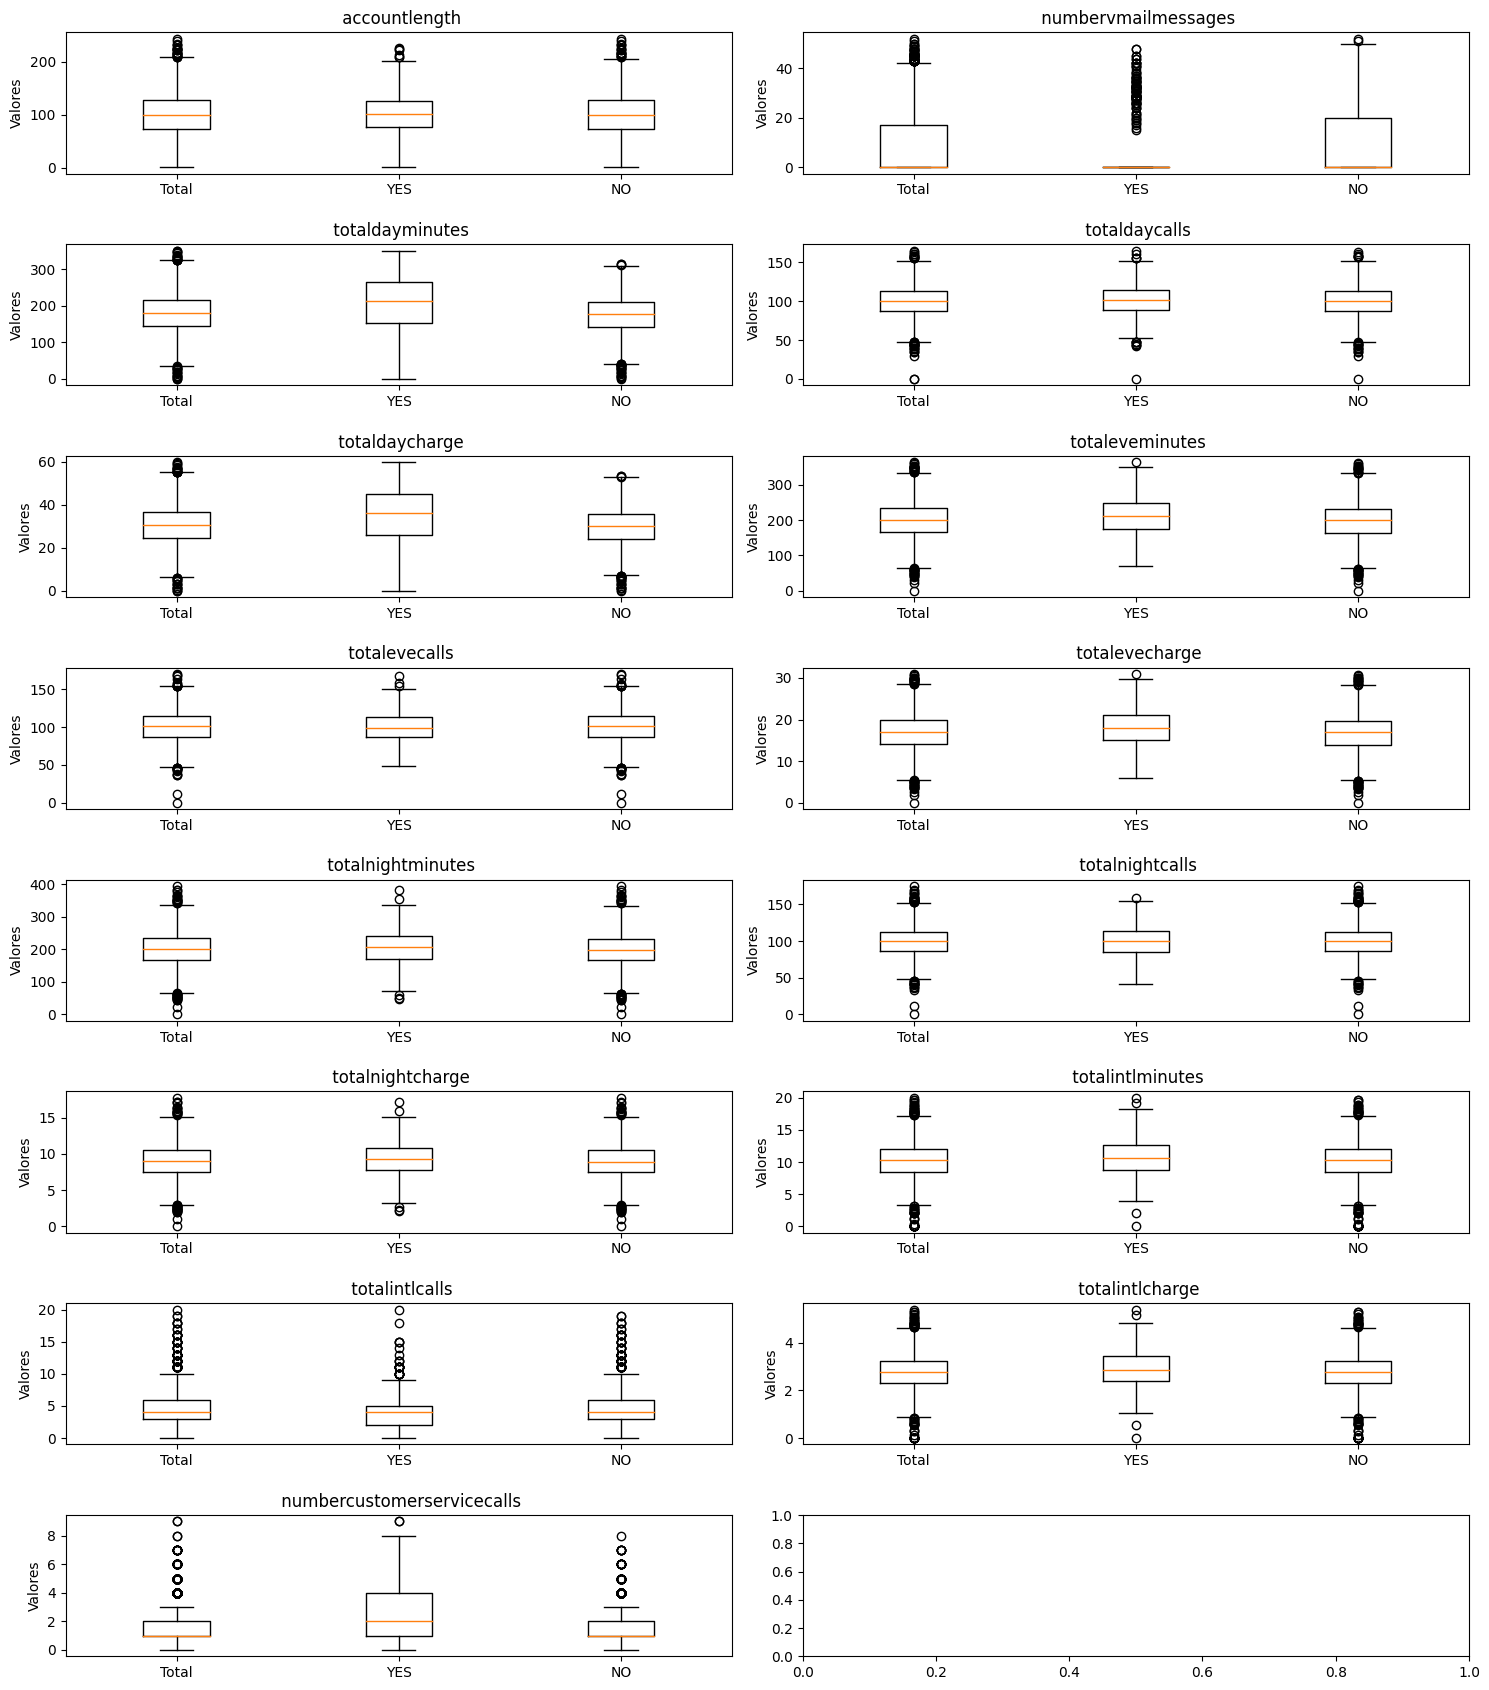

In [ ]:
# Cria uma figura com um grid 3x3 para os subplots
fig, axs = plt.subplots(8, 2, figsize=(15, 17))

# Variável para percorrer os subplots
axs = axs.flatten()

# Loop pelas colunas numéricas do DataFrame
numeric_columns = [coluna for coluna in churn_df.columns if np.issubdtype(churn_df[coluna].dtype, np.number)]

for i, coluna in enumerate(numeric_columns):

    # Cria os boxplots para 'Total', 'YES' e 'NO'
    axs[i].boxplot([churn_df[coluna].dropna(), churn_yes_df[coluna].dropna(), churn_no_df[coluna].dropna()],
                   labels=['Total', 'YES', 'NO'])

    # Define o título do boxplot com o nome da coluna
    axs[i].set_title(f' {coluna}')

    # Adiciona rótulos aos eixos
    axs[i].set_ylabel('Valores')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
# Mostra os subplots
plt.show()

### The importance of international and voicemail plan

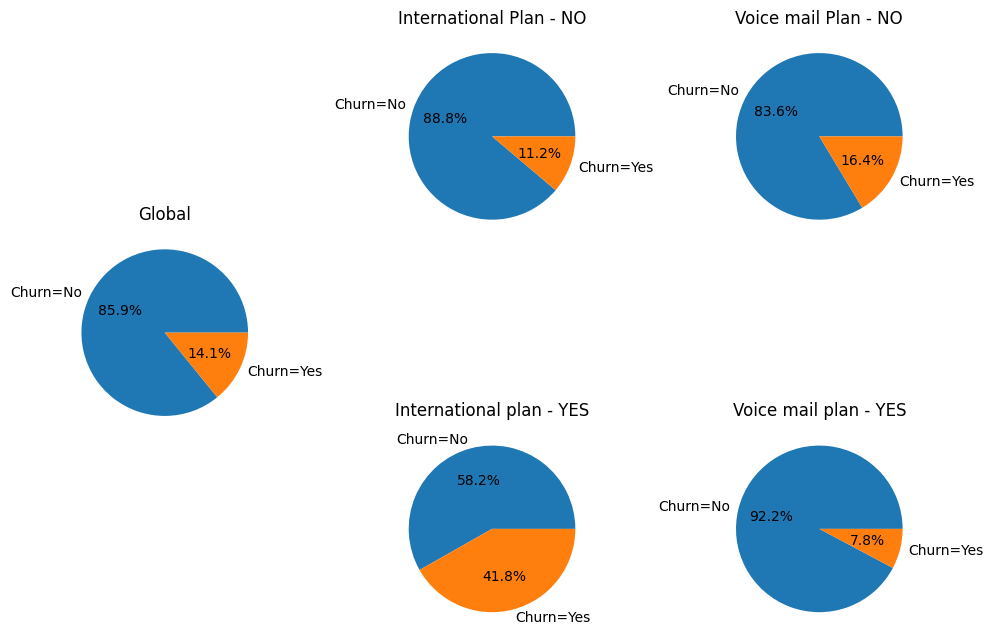

In [ ]:
# Conditions:
condition1 = churn_df['churn'] == 'No'
condition2 = churn_df['churn'] == 'Yes'
condition3 = churn_df['internationalplan'] == 'no'
condition4 = churn_df['internationalplan'] == 'yes'
condition5 = churn_df['voicemailplan'] == 'no'
condition6 = churn_df['voicemailplan'] == 'yes'

# No conditions

rows_count_nochurn = len(churn_df[condition1])/len(churn_df)
rows_count_yeschurn = len(churn_df[condition2])/len(churn_df)

# Counting rows that satisfy both conditions
rows_count_nochurn_nointernationapalan = len(churn_df[condition3 & condition1])/len(churn_df[condition3])
rows_count_nochurn_yesinternationapalan = len(churn_df[condition3 & condition2])/len(churn_df[condition3])
rows_count_yeschurn_nointernationapalan = len(churn_df[condition4 & condition1])/len(churn_df[condition4])
rows_count_yeschurn_yesinternationapalan = len(churn_df[condition4 & condition2])/len(churn_df[condition4])

rows_count_nochurn_novoicemailplan = len(churn_df[condition5 & condition1])/len(churn_df[condition3])
rows_count_nochurn_yesn_novoicemailplan = len(churn_df[condition5 & condition2])/len(churn_df[condition3])
rows_count_yeschurn_non_novoicemailplan = len(churn_df[condition6 & condition1])/len(churn_df[condition4])
rows_count_yeschurn_yesn_novoicemailplan = len(churn_df[condition6 & condition2])/len(churn_df[condition4])

fig = plt.figure(figsize=(10, 8))

# Creating a subplot that spans two rows in the first column
ax0 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)

# Subplots in the second column
ax1 = plt.subplot2grid((2, 3), (0, 1))
ax2 = plt.subplot2grid((2, 3), (1, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))
ax4 = plt.subplot2grid((2, 3), (1, 2))

# Primeiro gráfico de pizza
values0 = [rows_count_nochurn, rows_count_yeschurn]
categories0 = ['Churn=No', 'Churn=Yes']
ax0.pie(values0, labels=categories0, autopct='%1.1f%%')
ax0.set_title('Global')

# Primeiro gráfico de pizza
values1 = [rows_count_nochurn_nointernationapalan, rows_count_nochurn_yesinternationapalan]
categories1 = ['Churn=No', 'Churn=Yes']
ax1.pie(values1, labels=categories1, autopct='%1.1f%%')
ax1.set_title('International Plan - NO')

# Segundo gráfico de pizza
values2 = [rows_count_yeschurn_nointernationapalan, rows_count_yeschurn_yesinternationapalan]
categories2 = ['Churn=No', 'Churn=Yes']
ax2.pie(values2, labels=categories2, autopct='%1.1f%%')
ax2.set_title('International plan - YES')

# Terceiro gráfico de pizza
values3 = [rows_count_nochurn_novoicemailplan, rows_count_nochurn_yesn_novoicemailplan]
categories3 = ['Churn=No', 'Churn=Yes']
ax3.pie(values3, labels=categories3, autopct='%1.1f%%')
ax3.set_title('Voice mail Plan - NO')

# Quarto gráfico de pizza
values4 = [rows_count_yeschurn_non_novoicemailplan, rows_count_yeschurn_yesn_novoicemailplan]
categories4 = ['Churn=No', 'Churn=Yes']
ax4.pie(values4, labels=categories4, autopct='%1.1f%%')
ax4.set_title('Voice mail plan - YES')

plt.tight_layout()
plt.show()


Globally, the distribution between Churn yes and no is 85.9% and 14.1%, respectively. When adressing the churn through the lens of specific columns, we noticed that when the customers had an International plan the percentage of people that left increased three times. While the clients that had a Voicemail plan had a higher tendency to stay.

Radar

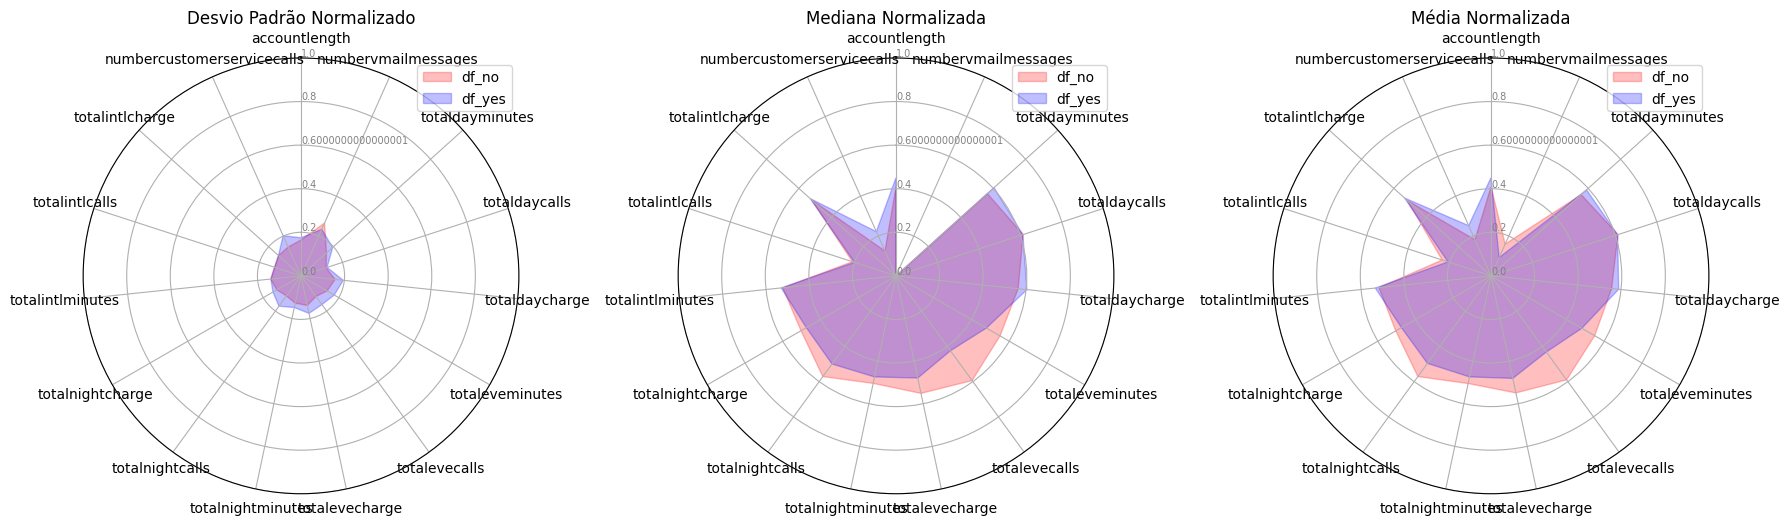

In [ ]:
# Supondo que você tenha df_no e df_yes como DataFrames

# Função para normalizar os valores de cada coluna entre 0 e 1
def normalize(df):
  return (df - df.min()) / (df.max() - df.min())

numeric_columns_no = churn_no_df.select_dtypes(include=np.number)
numeric_columns_yes = churn_yes_df.select_dtypes(include=np.number)

# Calcular os valores normalizados por coluna
normalized_no = normalize(numeric_columns_no)
normalized_yes = normalize(numeric_columns_yes)

# Calcular os valores std normalizados por coluna
std_values_no = normalized_no.std()
std_values_yes = normalized_yes.std()

# Calcular os valores mediana normalizados por coluna
med_values_no = normalized_no.median()
med_values_yes = normalized_yes.median()

# Calcular os valores média normalizados por coluna
mean_values_no = normalized_no.mean()
mean_values_yes = normalized_yes.mean()

# Atribuir as propriedades das colunas aos ângulos
properties = mean_values_no.index  # Propriedades das colunas
num_properties = len(properties)

# Definir os ângulos para as propriedades das colunas
angles = np.linspace(0, 2 * np.pi, num_properties, endpoint=False).tolist()
angles += angles[:1]

# Obter os valores médios normalizados como coordenadas para o gráfico de radar
std_values_no = std_values_no.values.tolist()
std_values_no += std_values_no[:1]  # Para fechar o gráfico
std_values_yes = std_values_yes.values.tolist()
std_values_yes += std_values_yes[:1]  # Para fechar o gráfico

med_values_no = med_values_no.values.tolist()
med_values_no += med_values_no[:1]  # Para fechar o gráfico
med_values_yes = med_values_yes.values.tolist()
med_values_yes += med_values_yes[:1]  # Para fechar o gráfico

mean_values_no = mean_values_no.values.tolist()
mean_values_no += mean_values_no[:1]  # Para fechar o gráfico
mean_values_yes = mean_values_yes.values.tolist()
mean_values_yes += mean_values_yes[:1]  # Para fechar o gráfico

# Criar os gráficos de radar
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

# Lista de títulos para os gráficos
titles = ['Desvio Padrão Normalizado', 'Mediana Normalizada', 'Média Normalizada']


for i, (values_no, values_yes, title) in enumerate(zip([std_values_no, med_values_no, mean_values_no],
                                                       [std_values_yes, med_values_yes, mean_values_yes],
                                                       titles)):
    ax = axs[i]
    # Plotar os gráficos de radar
    ax.fill(angles, values_no, color='red', alpha=0.25, label='df_no')
    ax.fill(angles, values_yes, color='blue', alpha=0.25, label='df_yes')
    ax.set_title(title)
    ax.set_ylim(0, 1)  # Ajustar os limites do eixo radial para 0 a 1
    ax.legend()

    ax.set_theta_offset(np.pi / 2)  # Ajustar o ângulo inicial
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(properties)
    ax.set_rlabel_position(0)
    ax.set_yticks(np.linspace(0, 1, 6))  # Definir os ticks do eixo radial
    ax.set_yticklabels(np.linspace(0, 1, 6), color="grey", size=7)  # Rótulos dos ticks do eixo radial

plt.tight_layout()
plt.show()


### Correlation Matrix

<ipython-input-14-cf82b2902ada>:9: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


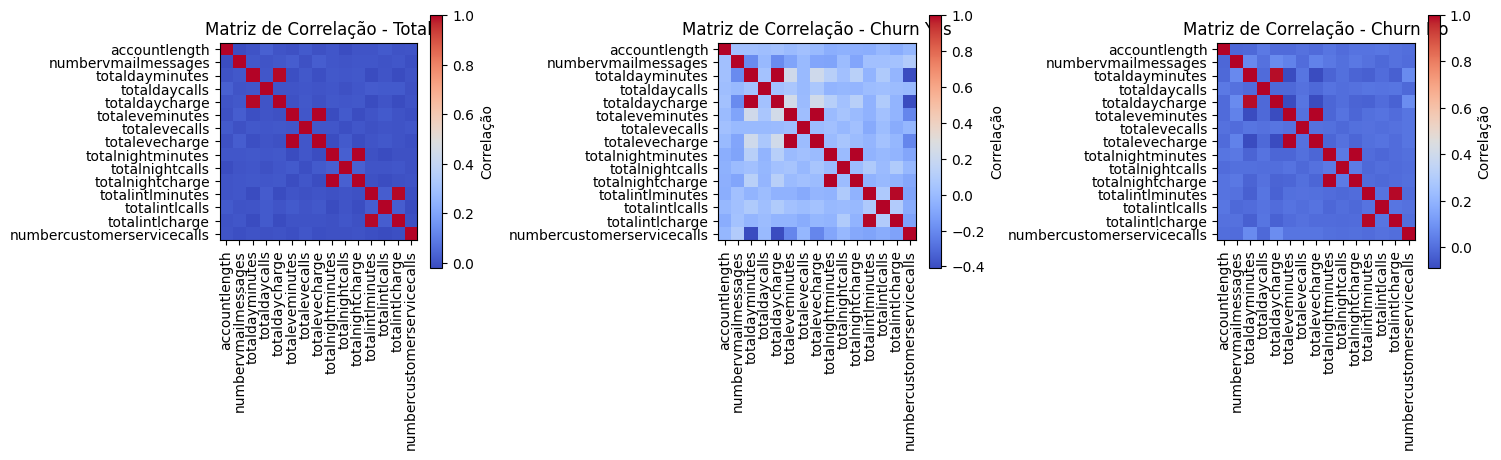

In [ ]:
df_plot = [churn_df, churn_yes_df, churn_no_df]
titles = ['Matriz de Correlação - Total', 'Matriz de Correlação - Churn Yes', 'Matriz de Correlação - Churn No']

fig, axes = plt.subplots(1, len(df_plot), figsize=(15, 5))



for i, df in enumerate(df_plot):
    correlation_matrix = df.corr()
    ax = axes[i]
    im = ax.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
    ax.set_title(titles[i])
    ax.set_xticks(range(len(correlation_matrix.columns)))
    ax.set_yticks(range(len(correlation_matrix.columns)))
    ax.set_xticklabels(correlation_matrix.columns, rotation=90)
    ax.set_yticklabels(correlation_matrix.columns)
    plt.colorbar(im, ax=ax, label='Correlação',   shrink=0.8)

plt.tight_layout()
plt.show()


By looking to each correlation matrix we can see there is no big difference between churn = yes or churn = no. There is also high correlation between some columns:

    -> The totalintlcharge is correlated with the totalintlminutes.
    -> The totalnightminutes and the totalnightcharge.
    -> The totalevecharge and the totaleveminutes.
    -> The totaldaycharge and totaldayminutes.

These correlations make sense because this corresponds to the value of minutes per call, so there is a constant price per minute.

This is important to know for the pre proccesing of the data in order to calculate the values that are missing for the correlated columns.

### Null values

In [ ]:
# Since the churn column does not have null values we are going to see if there is a row where all the other columns, less the churn columns, are null.
churn_df[churn_df.iloc[:, 1:].isnull().all(axis=1)]

,churn,accountlength,internationalplan,voicemailplan,numbervmailmessages,totaldayminutes,totaldaycalls,totaldaycharge,totaleveminutes,totalevecalls,totalevecharge,totalnightminutes,totalnightcalls,totalnightcharge,totalintlminutes,totalintlcalls,totalintlcharge,numbercustomerservicecalls


There isn't any row where all the columns are null.

In [ ]:
counts = churn_df.groupby(["churn", "voicemailplan"]).size()
print(counts)

churn  voicemailplan
No     no               3042
       yes              1210
Yes    no                596
       yes               102
dtype: int64


In [ ]:
print(churn_df.groupby(["voicemailplan", "numbervmailmessages"]).size())

voicemailplan  numbervmailmessages
no             0.0                    3600
yes            0.0                       1
               4.0                       1
               6.0                       2
               8.0                       2
               9.0                       2
               10.0                      4
               11.0                      2
               12.0                     11
               13.0                      4
               14.0                      8
               15.0                     13
               16.0                     17
               17.0                     21
               18.0                     18
               19.0                     26
               20.0                     32
               21.0                     41
               22.0                     44
               23.0                     52
               24.0                     64
               25.0                     50
               26.0

In [ ]:
print(churn_df.groupby(["voicemailplan", "numbervmailmessages", "churn"]).size())

voicemailplan  numbervmailmessages  churn
no             0.0                  No       3009
                                    Yes       591
yes            0.0                  No          1
               4.0                  No          1
               6.0                  No          2
                                             ... 
               48.0                 Yes         2
               49.0                 No          3
               50.0                 No          2
               51.0                 No          1
               52.0                 No          1
Length: 80, dtype: int64


In [ ]:
print('Number of duplicated values in the dataframe: ', churn_df.duplicated().sum())

Number of duplicated values in the dataframe:  0


# Data  Pre Processing

In [ ]:
churn_clean_df = churn_df.copy()

To remove the nulls we used different aproaches for diferent columns:

-> For the column voicemailplan, when numbermailmessages was bigger than 0 the null value was be replaced by yes, while the rest by no.

-> For the numbervmailmessages for the cases that the voicemailplan was 'no' the number would be 0, for the other cases we used the mean.

-> For the columns totalintlcharge, totalintlminutes, totalnightminutes, totalnightcharge, totalevecharge, totaleveminutes, totaldaycharge, totaldayminutes we calculated the values using the tax between them.

-> For the numbercustomerservicecalls used the mean for the null values.

In [ ]:
# When numbermailmessages bigger than the voicemailplan null value will be replaced by yes, and for for the rest cases will be no.
# As seen above only one case had 0 numbermailmessage and had a voiceplan.

def fill_na(row):
    if row['numbervmailmessages'] > 0:
        return 'yes'
    else:
        return 'no'

churn_clean_df['voicemailplan'] = churn_clean_df.apply(fill_na, axis=1)


def fill_nan(row):
    if pd.isna(row['numbervmailmessages']):
        if row['voicemailplan'] == "no":
            return 0.0
        else:
            return churn_clean_df['numbervmailmessages'].mean()
    else:
        return row['numbervmailmessages']

churn_clean_df['numbervmailmessages'] = churn_clean_df.apply(fill_nan, axis=1)

In [ ]:
#Calculation of tax value, to then fill the null values for the columns totalintlminutes, totalintlcharge, totalnightcharge, totalnightminutes, totalevecharge, totaleveminutes, totaldaycharge, totaldayminutes.

tax_totalintl = round(
    churn_df["totalintlcharge"] / churn_df["totalintlminutes"], 2
).mode()[0]
tax_totalnight = round(
    churn_df["totalnightcharge"] / churn_df["totalnightminutes"], 3
).mode()[0]
tax_totaleve = round(
    churn_df["totalevecharge"] / churn_df["totaleveminutes"], 3
).mode()[0]
tax_totalday = round(
    churn_df["totaldaycharge"] / churn_df["totaldayminutes"],2
).mode()[0]

print(tax_totalintl, tax_totalnight, tax_totaleve, tax_totalday)

0.27 0.045 0.085 0.17


In [ ]:
churn_clean_df['accountlength'].fillna(churn_clean_df['accountlength'].mean(), inplace=True)
churn_clean_df['internationalplan'].fillna(churn_clean_df['internationalplan'].mode()[0], inplace=True)

churn_clean_df['totalintlcharge'].fillna((churn_clean_df["totalintlminutes"]*tax_totalintl), inplace=True)
churn_clean_df['totalintlminutes'].fillna((churn_clean_df["totalintlcharge"]/tax_totalintl), inplace=True)

churn_clean_df['totalnightcharge'].fillna((churn_clean_df["totalnightminutes"]*tax_totalnight), inplace=True)
churn_clean_df['totalnightminutes'].fillna((churn_clean_df["totalnightcharge"]/tax_totalnight), inplace=True)

churn_clean_df['totalevecharge'].fillna((churn_clean_df["totaleveminutes"]*tax_totaleve), inplace=True)
churn_clean_df['totaleveminutes'].fillna((churn_clean_df["totalevecharge"]/tax_totaleve), inplace=True)

churn_clean_df['totaldaycharge'].fillna((churn_clean_df["totaldayminutes"]*tax_totalday), inplace=True)
churn_clean_df['totaldayminutes'].fillna((churn_clean_df["totaldaycharge"]/tax_totalday), inplace=True)

churn_clean_df['numbercustomerservicecalls'].fillna(churn_clean_df['numbercustomerservicecalls'].mean(), inplace=True)

In [ ]:
churn_clean_df['churn'] = churn_clean_df['churn'].map({'Yes': 1, 'No': 0})
churn_clean_df['internationalplan'] = churn_clean_df['internationalplan'].map({'yes': 1, 'no': 0})
churn_clean_df['voicemailplan'] = churn_clean_df['voicemailplan'].map({'yes': 1, 'no': 0})

In [ ]:
churn_clean_df[churn_clean_df['totalintlminutes'].isna()]

,churn,accountlength,internationalplan,voicemailplan,numbervmailmessages,totaldayminutes,totaldaycalls,totaldaycharge,totaleveminutes,totalevecalls,totalevecharge,totalnightminutes,totalnightcalls,totalnightcharge,totalintlminutes,totalintlcalls,totalintlcharge,numbercustomerservicecalls
4071,0,26.0,0,0,0.0,83.2,93.0,14.14,199.5,64.0,16.96,242.6,112.0,10.92,NaN,4.0,NaN,1.0


To choose the columns that would be removed, we looked at the correlations between each other.
 After the data understanding step we also decided to remove the columns that had a low correlation with the data being churn or not. The columns chosen to be removed were:
'numbervmailmessages','totaldaycharge','totalnightcharge','totalevecharge','totalintlcharge','totaldaycalls','totalnightcalls','totalevecalls','totalintlcalls'

In order to get a simpler model the numbervmailmessage was also removed since it had great correlation with the voicemailplan column indicating that information gathered from both columns were similar.

The columns 'totaldaycharge','totalnightcharge','totalevecharge','totalintlcharge' are correlated with the corresponding minutes column so we decided to only keep the minutes columns.

The columns totaldaycalls','totalnightcalls','totalevecalls','totalintlcalls' presented the lowest relation to the churn column, so they were removed.

In [ ]:
churn_clean_df = churn_clean_df.drop(columns=['numbervmailmessages','totaldaycharge','totalnightcharge','totalevecharge','totalintlcharge','totaldaycalls','totalnightcalls','totalevecalls','totalintlcalls'])

In [ ]:
#Drop the column that is na (it didin't had the value for the totalintlminutes or totalintcharge to be calculated)
churn_clean_df = churn_clean_df.dropna(subset=['totalintlminutes'])

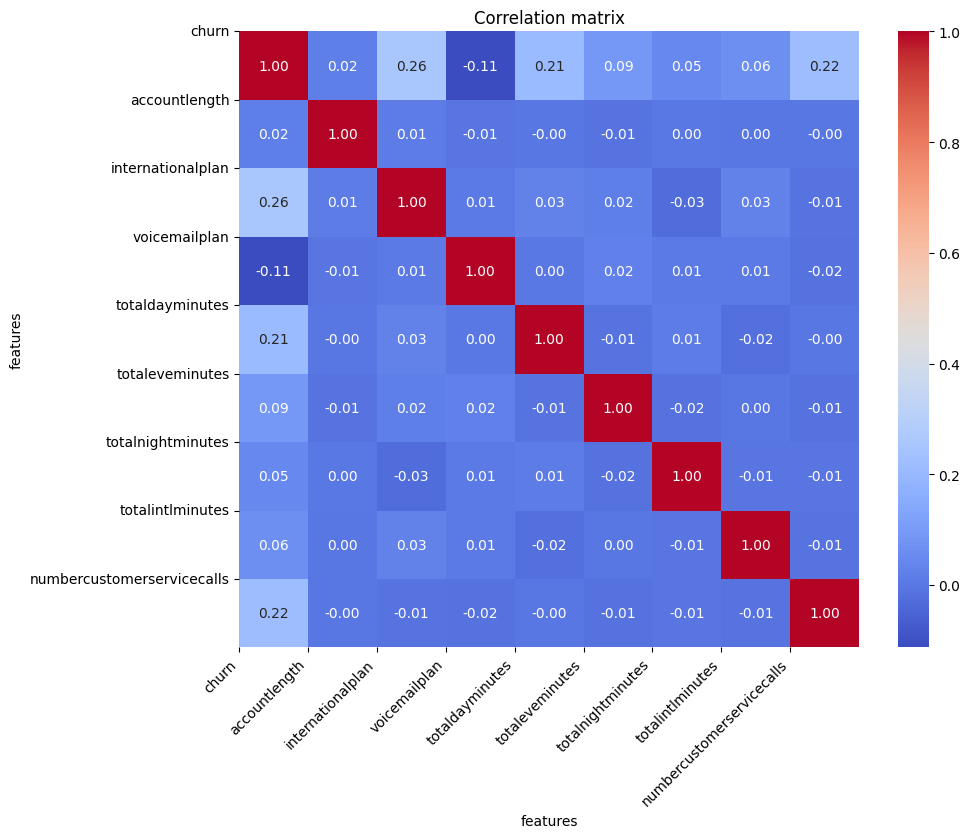

In [ ]:
correlation_matrix = churn_clean_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")

plt.title('Correlation matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=0)
plt.xlabel('features')
plt.ylabel('features')
plt.show()


As it is possible to see from the correlation matrix, we now don't have high correlated columns.

In [ ]:
churn_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4999 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   churn                       4999 non-null   int64  
 1   accountlength               4999 non-null   float64
 2   internationalplan           4999 non-null   int64  
 3   voicemailplan               4999 non-null   int64  
 4   totaldayminutes             4999 non-null   float64
 5   totaleveminutes             4999 non-null   float64
 6   totalnightminutes           4999 non-null   float64
 7   totalintlminutes            4999 non-null   float64
 8   numbercustomerservicecalls  4999 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 390.5 KB


Also we don't have null rows

In [ ]:
print(churn_clean_df['churn'].unique())
print(churn_clean_df['internationalplan'].unique())
print(churn_clean_df['voicemailplan'].unique())

[0 1]
[0 1]
[1 0]


# Modeling

Before testing the differet models, the dataframe was firstly divided in test data and train data with a ratio of 80/20.

In [ ]:
target_column = 'churn'

X = churn_clean_df.drop(target_column, axis=1)
y = churn_clean_df[target_column]

#Here we will create a Tr and Ts with the racio of 80/20

X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, train_size=0.8, random_state=123)

print(f" Train churn -> {y_tr.value_counts()/y_tr.count() * 100}")
print(f" Test churn -> {y_ts.value_counts()/y_ts.count() * 100}")



 Train churn -> 0    86.096524
1    13.903476
Name: churn, dtype: float64
 Test churn -> 0    84.9
1    15.1
Name: churn, dtype: float64


The train data and the test data are unbalanced, as we already saw in the data understanding step.

We created 3 different types of balanced train data.
The first one being the UNDERSAMPLED data set that remove data from the high value class until reaches the same number as the lower one.The OVERSAMPLE that duplicates the lower class values until it reaches the same number as the majority class. Finally, the SMOTE(Synthetic Minority Over-sampling) predict values for the lower class until reaches the same amount as the majority class.

In [ ]:
#The method used in this case to get a balanced data was the undersampling
undersampler = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = undersampler.fit_resample(X_tr, y_tr)
print(f" churn -> {y_undersampled.value_counts()}")
counter = Counter(y_undersampled)
print(counter)

 churn -> 0    556
1    556
Name: churn, dtype: int64
Counter({0: 556, 1: 556})


In [ ]:
#The method used in this case to get a balanced data was the SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_tr, y_tr)
counter = Counter(y_smote)
print(counter)

Counter({0: 3443, 1: 3443})


In [ ]:
#The method used in this case to get a balanced data was the oversample
oversample = RandomOverSampler(random_state=42)
X_oversampled, y_oversampled = oversample.fit_resample(X_tr, y_tr)
counter = Counter(y_oversampled)
print(counter)

Counter({0: 3443, 1: 3443})


In [ ]:
#General dictionary with the different types of train dataset we have
dict_train_samplers={'undersampled':{'x':X_undersampled,'y':y_undersampled},
              'smote':{'x':X_smote,'y':y_smote},
              'oversample':{'x':X_oversampled,'y':y_oversampled},
              'unbalance':{'x':X_tr,'y':y_tr}
              }

In [ ]:
grid_search=False

In [ ]:
df_result = pd.DataFrame(columns=['Model','Text','Accuracy','Precision', 'Recall', 'F1-score'])

def model_evaluation(y,y_pred,text='TRAIN',save=False, model='SVM'):

  print(text)

  cm = confusion_matrix(y, y_pred)
  print(cm)

  report=classification_report(y, y_pred,target_names=['churn=NO','churn=YES'],output_dict=False)

  print(report)

  report=classification_report(y, y_pred,target_names=['churn=NO','churn=YES'],output_dict=True)

  if save==True:

    global df_result

    new_row = {
            'Model': model,
            'Text': text,
            'Accuracy': "{:.2f}%".format(report['accuracy'] * 100),
            'Precision': "{:.2f}%".format(report['churn=YES']['precision'] * 100),
            'Recall': "{:.2f}%".format(report['churn=YES']['recall'] * 100),
            'F1-score': "{:.2f}%".format(report['churn=YES']['f1-score'] * 100),
            'F1-score_yes':report['churn=YES']['f1-score'],
            'Recall_yes': report['churn=YES']['recall'],
            'Precision_yes': report['churn=YES']['precision'],
            'Accuracy': report['accuracy'],
            'Precision_no': report['churn=NO']['precision'],
            'Recall_no': report['churn=NO']['recall'],
            'F1-score_no': report['churn=NO']['f1-score']
        }
    df_to_append = pd.DataFrame([new_row])
    df_result = pd.concat([df_result, df_to_append], ignore_index=True)


## Nearest neighbor

The parameter n_neighbors for the Nearest neighbor model was evaluated using GridSearchCV. The best values within an interval that started at 3 to 50 were saved in the dictionary named dict_hyperparameters_knn. The search for the best parameter was done for each type of dataset.
The interval for the grid search started at 3, to minimize overfitting.

In [ ]:
#Using grid search to find the n_neigbor for each type of dataset
parameter = {'n_neighbors': np.arange(3, 50)}
grid_search = False

dict_hyperparameters_knn ={'undersampled':{'n':27,},  #(40, 19, 5, 56)
                      'smote':{'n':4},    #(3,4)
                      'oversample':{'n':4},   #(3,4)
                      'unbalance':{'n':9}}     #(5, 11, 3)

scoring_type = ['f1_weighted']  #'f1', 'accuracy', 'recall', 'scoring',
scoring = {
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, average='weighted'),
            'recall': make_scorer(recall_score, average='weighted'),
            'f1': make_scorer(f1_score, average='weighted')
          }
# grid search cross validation
for dataset in dict_train_samplers.keys():
  print(dataset)
  x_sample = dict_train_samplers[dataset]['x']
  y_sample = dict_train_samplers[dataset]['y']

  if grid_search:
    for score in  scoring_type:
        knn = KNeighborsClassifier()
        if score == 'scoring':
          grid_search_m = GridSearchCV(KNeighborsClassifier(), param_grid=parameter, cv=10, scoring=scoring, refit='f1')
          grid_search_m.fit(x_sample, y_sample)
          results_df = pd.DataFrame(grid_search_m.cv_results_)
          sort_results = results_df.sort_values(by='mean_test_f1', ascending=False)
          print("Top Two Parameter Combinations:")
          print(sort_results[['params', 'mean_test_f1']].head(2))
        else:
          grid_search_m = GridSearchCV(KNeighborsClassifier(), param_grid=parameter, cv=10, scoring=score)
          grid_search_m.fit(x_sample, y_sample)
          results_df = pd.DataFrame(grid_search_m.cv_results_)
          sort_results = results_df.sort_values(by='mean_test_score', ascending=False)
          print("Top Two Parameter Combinations:")
          print(sort_results[['params', 'mean_test_score']].head(2))
        best_params = grid_search_m.best_params_
        print(f"grid search using {score}: best paramaters -> {best_params}")
        print(f"better accuracy: ", (grid_search_m.best_score_)**(1/2.0))
        model_knn = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'])

  else:
    model_knn = KNeighborsClassifier(n_neighbors=dict_hyperparameters_knn[dataset]['n'])
    model_knn.fit(x_sample, y_sample)

  # Model train

  model_knn.fit(x_sample, dict_train_samplers[dataset]['y'])

  # Train value
  y_tr_pred = model_knn.predict(x_sample)
  model_evaluation(y_sample,y_tr_pred,text='TRAIN '+str(dataset),save=True,model='KNN')

  # Holdout
  y_ts_pred = model_knn.predict(X_ts)
  model_evaluation(y_ts,y_ts_pred,text='TEST '+str(dataset),save=True,model='KNN')

  print(classification_report(y_ts, y_ts_pred))


undersampled
TRAIN undersampled
[[454 102]
 [235 321]]
              precision    recall  f1-score   support

    churn=NO       0.66      0.82      0.73       556
   churn=YES       0.76      0.58      0.66       556

    accuracy                           0.70      1112
   macro avg       0.71      0.70      0.69      1112
weighted avg       0.71      0.70      0.69      1112

TEST undersampled
[[666 183]
 [ 64  87]]
              precision    recall  f1-score   support

    churn=NO       0.91      0.78      0.84       849
   churn=YES       0.32      0.58      0.41       151

    accuracy                           0.75      1000
   macro avg       0.62      0.68      0.63      1000
weighted avg       0.82      0.75      0.78      1000

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       849
           1       0.32      0.58      0.41       151

    accuracy                           0.75      1000
   macro avg       0.62      0.6

In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('KNN'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score
1,KNN,TEST undersampled,0.753,32.22%,57.62%,41.33%
3,KNN,TEST smote,0.772,33.04%,49.67%,39.68%
5,KNN,TEST oversample,0.777,33.64%,49.01%,39.89%
7,KNN,TEST unbalance,0.874,71.19%,27.81%,40.00%


By looking at the results the KNN model is not a good model for this problem. The F1 score for the churn = yes is low with a maximum value of 41,33 for the undersample data set.

## NaiveBayes

In [ ]:
print(X_tr.head(2))

      accountlength  internationalplan  voicemailplan  totaldayminutes  \
1863      94.000000                  1              0            170.1   
420       28.499134                  0              1            206.9   

      totaleveminutes  totalnightminutes  totalintlminutes  \
1863            271.8              110.7               8.7   
420             264.4              171.8               9.3   

      numbercustomerservicecalls  
1863                         1.0  
420                          2.0  


The naive model chosen was the mixed Naive Bayes, because we have two categorical features, internationalplan position 1, and voicemailplan position 2.

In [ ]:
# MIXED NAIVE BAYES
for dataset in dict_train_samplers.keys():
    print(dataset)
    x_sample = dict_train_samplers[dataset]['x']
    y_sample = dict_train_samplers[dataset]['y']
    model_nb = MixedNB(categorical_features=[1,2])

    # Train value
    y_tr_pred = model_nb.fit(x_sample, y_sample).predict(x_sample)
    model_evaluation(y_sample, y_tr_pred, text=f'TRAIN {dataset}', save=True, model='NB')

    #Cross validation
    cross_validation_nb = cross_val_score(model_nb, x_sample, y_sample, cv=10)

    print('MixedNB')
    print(f"Avg Score cross-validation -> {np.mean(cross_validation_nb)}")

    # Holdout
    y_ts_pred = model_nb.predict(X_ts)
    model_evaluation(y_ts, y_ts_pred, text=f'TEST {dataset}', save=True, model='NB')


undersampled
TRAIN undersampled
[[456 100]
 [ 99 457]]
              precision    recall  f1-score   support

    churn=NO       0.82      0.82      0.82       556
   churn=YES       0.82      0.82      0.82       556

    accuracy                           0.82      1112
   macro avg       0.82      0.82      0.82      1112
weighted avg       0.82      0.82      0.82      1112

MixedNB
Avg Score cross-validation -> 0.8075450450450452
TEST undersampled
[[709 140]
 [ 22 129]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.84      0.90       849
   churn=YES       0.48      0.85      0.61       151

    accuracy                           0.84      1000
   macro avg       0.72      0.84      0.76      1000
weighted avg       0.90      0.84      0.85      1000

smote
TRAIN smote
[[2665  778]
 [ 713 2730]]
              precision    recall  f1-score   support

    churn=NO       0.79      0.77      0.78      3443
   churn=YES       0.78      0.79      

/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':
/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':


MixedNB
Avg Score cross-validation -> 0.781451252236136
TEST smote
[[666 183]
 [ 41 110]]
              precision    recall  f1-score   support

    churn=NO       0.94      0.78      0.86       849
   churn=YES       0.38      0.73      0.50       151

    accuracy                           0.78      1000
   macro avg       0.66      0.76      0.68      1000
weighted avg       0.86      0.78      0.80      1000

oversample
TRAIN oversample
[[2826  617]
 [ 637 2806]]
              precision    recall  f1-score   support

    churn=NO       0.82      0.82      0.82      3443
   churn=YES       0.82      0.81      0.82      3443

    accuracy                           0.82      6886
   macro avg       0.82      0.82      0.82      6886
weighted avg       0.82      0.82      0.82      6886

MixedNB
Avg Score cross-validation -> 0.8189050528234383
TEST oversample
[[704 145]
 [ 24 127]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.83      0.89       

/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':
/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
/usr/local/lib/python3.10/dist-packages/mixed_naive_bayes/mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':


              precision    recall  f1-score   support

    churn=NO       0.89      0.98      0.93      3443
   churn=YES       0.63      0.24      0.35       556

    accuracy                           0.87      3999
   macro avg       0.76      0.61      0.64      3999
weighted avg       0.85      0.87      0.85      3999

MixedNB
Avg Score cross-validation -> 0.8734686716791981
TEST unbalance
[[829  20]
 [114  37]]
              precision    recall  f1-score   support

    churn=NO       0.88      0.98      0.93       849
   churn=YES       0.65      0.25      0.36       151

    accuracy                           0.87      1000
   macro avg       0.76      0.61      0.64      1000
weighted avg       0.84      0.87      0.84      1000



We also tested the Gaussian model. Most of the numeric features follow a normal distribution.

In [ ]:
for dataset in dict_train_samplers.keys():
    print(dataset)
    x_sample = dict_train_samplers[dataset]['x']
    y_sample = dict_train_samplers[dataset]['y']

    model_nb_gau = GaussianNB().fit(x_sample, y_sample)

    # Train value

    y_tr_pred = model_nb_gau.predict(x_sample)
    model_evaluation(y_sample, y_tr_pred, text=f'TRAIN {dataset}', save=True, model='NBG')

    #Cross validation
    cross_validation_nb = cross_val_score(model_nb_gau, x_sample, y_sample, cv=10, scoring='f1')

    print('Cross validation Gaussian')
    print(f"Avg Score cross-validation -> {np.mean(cross_validation_nb)}")

    # Holdout
    y_ts_pred = model_nb_gau.predict(X_ts)
    model_evaluation(y_ts, y_ts_pred, text=f'TEST {dataset}', save=True, model='NBG')

undersampled
TRAIN undersampled
[[481  75]
 [139 417]]
              precision    recall  f1-score   support

    churn=NO       0.78      0.87      0.82       556
   churn=YES       0.85      0.75      0.80       556

    accuracy                           0.81      1112
   macro avg       0.81      0.81      0.81      1112
weighted avg       0.81      0.81      0.81      1112

Cross validation Gaussian
Avg Score cross-validation -> 0.7841895268334756
TEST undersampled
[[743 106]
 [ 30 121]]
              precision    recall  f1-score   support

    churn=NO       0.96      0.88      0.92       849
   churn=YES       0.53      0.80      0.64       151

    accuracy                           0.86      1000
   macro avg       0.75      0.84      0.78      1000
weighted avg       0.90      0.86      0.87      1000

smote
TRAIN smote
[[2011 1432]
 [ 417 3026]]
              precision    recall  f1-score   support

    churn=NO       0.83      0.58      0.69      3443
   churn=YES       0.

In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('NB'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score
9,NB,TEST undersampled,0.838,47.96%,85.43%,61.43%
11,NB,TEST smote,0.776,37.54%,72.85%,49.55%
13,NB,TEST oversample,0.831,46.69%,84.11%,60.05%
15,NB,TEST unbalance,0.866,64.91%,24.50%,35.58%
17,NBG,TEST undersampled,0.864,53.30%,80.13%,64.02%
19,NBG,TEST smote,0.640,27.23%,82.78%,40.98%
21,NBG,TEST oversample,0.861,52.56%,81.46%,63.90%
23,NBG,TEST unbalance,0.850,50.39%,42.38%,46.04%


By looking at the general results for the mixed Naive Bayes, we have good values. The model wiht highest 'F1-Score(CHURN=YES)'  was the 'UNDERSAMPLED' dataset  with 61%. Despite the low 'Precision'(48%) there was a good 'Recall'(85%) value indicating that the most of the customers that will leave are identified. For the Gaussian Naive Bayes model the maximum 'F1-Score' was 64% for the 'UNDERSAMPLED' dataset, which also had similar results to the 'UNDERSAMPLED' mixed Naive Bayes(low 'Precision' and high 'Recall'). Comparing both the mixed Naive Bayes and Gaussian Naive bayes, the 'F1-Scores(CHURN=YES)' in 'NBG' had a tendency to have better results(with exception of 'SMOTE').

## Decision Tree

The parameters for the Decision Tree were used by creating a GridSearchCV contianing a list of a max_depth of 21 values.The min_split leaf and max_leaf nodes parameters were considered but were removed for the model simplicity and to minimize overfitting. The ccp_alpha parameter was used but since the gird search values resulted in ccp_alpha=0, the parameter was also removed for further simplicity.

undersampled
TRAIN undersampled
[[530  26]
 [ 69 487]]
              precision    recall  f1-score   support

    churn=NO       0.88      0.95      0.92       556
   churn=YES       0.95      0.88      0.91       556

    accuracy                           0.91      1112
   macro avg       0.92      0.91      0.91      1112
weighted avg       0.92      0.91      0.91      1112

TEST undersampled
[[753  96]
 [ 26 125]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.89      0.93       849
   churn=YES       0.57      0.83      0.67       151

    accuracy                           0.88      1000
   macro avg       0.77      0.86      0.80      1000
weighted avg       0.91      0.88      0.89      1000



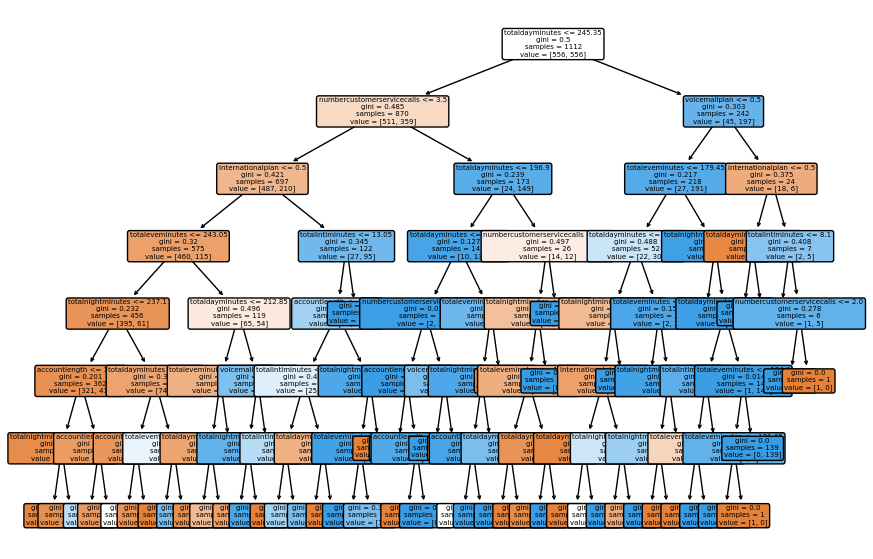

smote
TRAIN smote
[[3372   71]
 [ 161 3282]]
              precision    recall  f1-score   support

    churn=NO       0.95      0.98      0.97      3443
   churn=YES       0.98      0.95      0.97      3443

    accuracy                           0.97      6886
   macro avg       0.97      0.97      0.97      6886
weighted avg       0.97      0.97      0.97      6886

TEST smote
[[807  42]
 [ 42 109]]
              precision    recall  f1-score   support

    churn=NO       0.95      0.95      0.95       849
   churn=YES       0.72      0.72      0.72       151

    accuracy                           0.92      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.92      0.92      0.92      1000



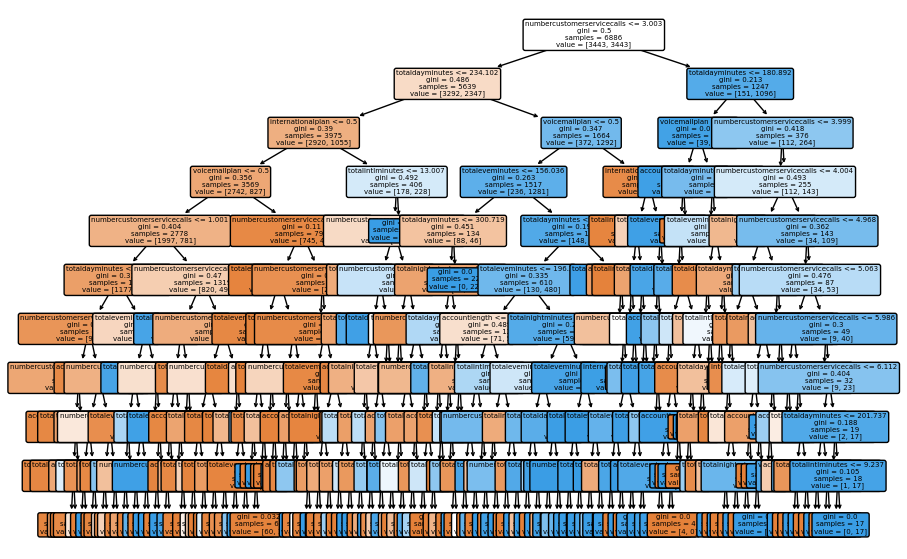

oversample
TRAIN oversample
[[3314  129]
 [ 372 3071]]
              precision    recall  f1-score   support

    churn=NO       0.90      0.96      0.93      3443
   churn=YES       0.96      0.89      0.92      3443

    accuracy                           0.93      6886
   macro avg       0.93      0.93      0.93      6886
weighted avg       0.93      0.93      0.93      6886

TEST oversample
[[807  42]
 [ 40 111]]
              precision    recall  f1-score   support

    churn=NO       0.95      0.95      0.95       849
   churn=YES       0.73      0.74      0.73       151

    accuracy                           0.92      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.92      0.92      0.92      1000



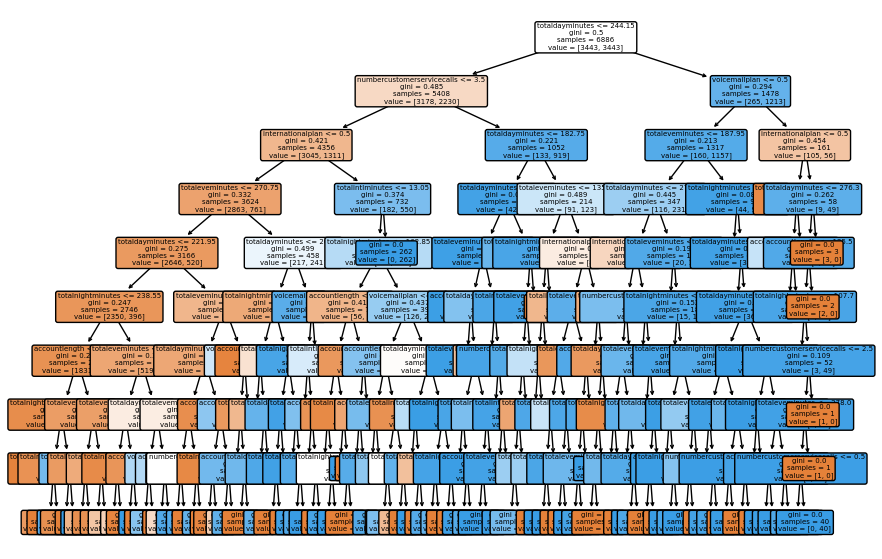

unbalance
TRAIN unbalance
[[3436    7]
 [ 147  409]]
              precision    recall  f1-score   support

    churn=NO       0.96      1.00      0.98      3443
   churn=YES       0.98      0.74      0.84       556

    accuracy                           0.96      3999
   macro avg       0.97      0.87      0.91      3999
weighted avg       0.96      0.96      0.96      3999

TEST unbalance
[[836  13]
 [ 49 102]]
              precision    recall  f1-score   support

    churn=NO       0.94      0.98      0.96       849
   churn=YES       0.89      0.68      0.77       151

    accuracy                           0.94      1000
   macro avg       0.92      0.83      0.87      1000
weighted avg       0.94      0.94      0.93      1000



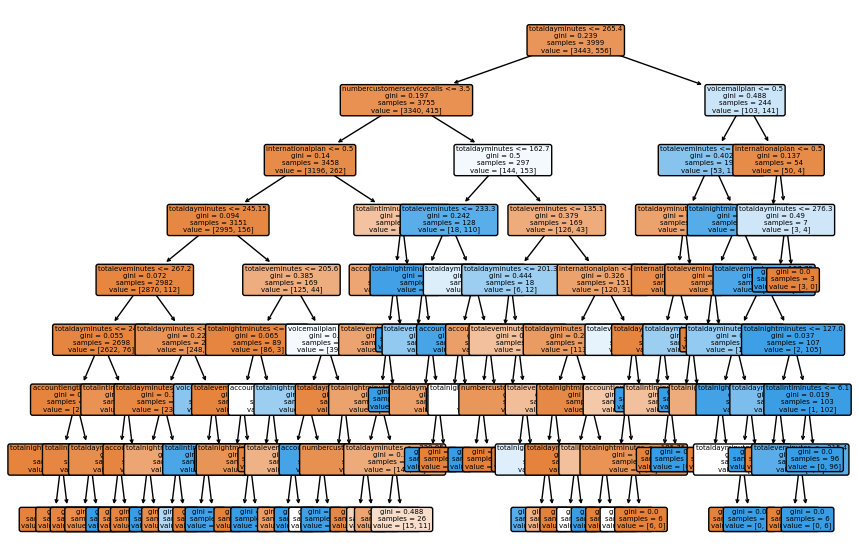

In [ ]:
# Define the parameter distribution

param_distDT =[{'max_depth': list(range(1, 21))}]

DTdict_hyperparameters={'undersampled':{'max_depth': 7},
                      'smote':{'max_depth': 10},
                      'oversample':{'max_depth': 9},
                      'unbalance':  {'max_depth': 8}}

dt=DecisionTreeClassifier()


for dataset in dict_train_samplers.keys():

  print(dataset)

  if grid_search:

    DT_clf = GridSearchCV(DecisionTreeClassifier(random_state=42),param_distDT, cv=10, scoring='f1')

  else:

    DT_clf=DecisionTreeClassifier(max_depth=DTdict_hyperparameters[dataset]['max_depth'],random_state=42)

  # Model train
  DT_clf.fit(dict_train_samplers[dataset]['x'], dict_train_samplers[dataset]['y'])

  if grid_search==True:
      print("Best parameters:", DT_clf.best_params_)
      print("better accuracy: ", (DT_clf.best_score_)**(1/2.0))

  # Previsões usando o conjunto de treino
  y_tr_pred = DT_clf.predict(dict_train_samplers[dataset]['x'])
  model_evaluation(dict_train_samplers[dataset]['y'],y_tr_pred,text='TRAIN '+str(dataset),save=True,model='DT')

  # Prever usando o conjunto de teste
  y_ts_pred = DT_clf.predict(X_ts)
  model_evaluation(y_ts,y_ts_pred,text='TEST '+str(dataset),save=True,model='DT')

  plt.figure(figsize=(10,7))
  plot_tree(DT_clf, fontsize=5, filled=True, rounded=True, feature_names=dict_train_samplers[dataset]['x'].columns)
  plt.show()

In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('DT'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score
25,DT,TEST undersampled,0.878,56.56%,82.78%,67.20%
27,DT,TEST smote,0.916,72.19%,72.19%,72.19%
29,DT,TEST oversample,0.918,72.55%,73.51%,73.03%
31,DT,TEST unbalance,0.938,88.70%,67.55%,76.69%


When comparing the train and test models' results the weighted performances  are similar (recall, precision, accuracy and F1-score), indicating no overfitting. After getting the results for all dataset, the balanced model with the highest F1-Score for Churn=Yes was "OVERSAMPLE" with 73%. The rest of the balanced models had similar measure results with a difference of 5-10%, the only exception being the precision of the "UNDERSAMPLE" test which could be due to a loss of information in the majority class (Churn=N0), meaning it didn't adequately learn its characteristics. Despite these results, the highest 'F1-Score (CHURN=YES)' came from the "UNBALANCED" model with 77%. When analysing each measure (recall, precision, accuracy and F1-score), we see a significant increase in Precision while a slight decrease in Recall, meaning the model is good (89%) at being sure about its predictions when it says a customer will churn. But, it's worse  at catching the customers who will churn (68%), missing about a third of them. When analysing the plots of each decision tree, most models started with the division of 'totaldayminutes' being smaller than around 250. The "SMOTE" model started with 'numbercustomerservicecalls' being higher than 3.

## Random Forest Classifiers

The scikit module used to fine-tune the hyperparameters for the Random Forest Classifier was the RandomizedSearchCV (k-folds fixed and equal to 10). Despite being less exhaustive than GridSearchCv we thought it would be a good option since despite not reaching the exact best condition it is a much faster module and useful for large search spaces. The parameters considered were 'n_estimators' and 'max_depth'. Most of the models used the same parameter values with the exception of the 'undersampled' data, which had the same 'max_depth' but a slightly higher 'n_estimators'.

In [ ]:
# Define the parameter distribution

param_distRF =[{'n_estimators': list(range(1, 200)), 'max_depth': list(range(1, 10))}]

dict_hyperparameters_rf={'undersampled':{'n_estimators':176,'max_depth':9},
                      'smote':{'n_estimators':134,'max_depth':9},
                      'oversample':{'n_estimators':134,'max_depth':9},
                      'unbalance':{'n_estimators':134,'max_depth':9}}

rf=RandomForestClassifier()

# Instantiate the grid

for dataset in dict_train_samplers.keys():

  print(dataset)

  if grid_search:

    rf_clf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                                param_distRF,
                                cv=10,
                                scoring='f1',
                                n_iter=10,
                                random_state=5)

  else:

    rf_clf=RandomForestClassifier(n_estimators=dict_hyperparameters_rf[dataset]['n_estimators'],max_depth=dict_hyperparameters_rf[dataset]['max_depth'],random_state=42)

  # Model train
  rf_clf.fit(dict_train_samplers[dataset]['x'], dict_train_samplers[dataset]['y'])

  if grid_search==True:
      print("Best parameters:", rf_clf.best_params_)
      print("better accuracy: ", (rf_clf.best_score_)**(1/2.0))

  # Previsões usando o conjunto de treino
  y_tr_pred = rf_clf.predict(dict_train_samplers[dataset]['x'])
  model_evaluation(dict_train_samplers[dataset]['y'],y_tr_pred,text='TRAIN '+str(dataset),save=True,model='RF')

  # Prever usando o conjunto de teste
  y_ts_pred = rf_clf.predict(X_ts)
  model_evaluation(y_ts,y_ts_pred,text='TEST '+str(dataset),save=True,model='RF')

undersampled
TRAIN undersampled
[[555   1]
 [ 62 494]]
              precision    recall  f1-score   support

    churn=NO       0.90      1.00      0.95       556
   churn=YES       1.00      0.89      0.94       556

    accuracy                           0.94      1112
   macro avg       0.95      0.94      0.94      1112
weighted avg       0.95      0.94      0.94      1112

TEST undersampled
[[756  93]
 [ 23 128]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.89      0.93       849
   churn=YES       0.58      0.85      0.69       151

    accuracy                           0.88      1000
   macro avg       0.77      0.87      0.81      1000
weighted avg       0.91      0.88      0.89      1000

smote
TRAIN smote
[[3341  102]
 [ 575 2868]]
              precision    recall  f1-score   support

    churn=NO       0.85      0.97      0.91      3443
   churn=YES       0.97      0.83      0.89      3443

    accuracy                           0.

In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('RF'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score
33,RF,TEST undersampled,0.884,57.92%,84.77%,68.82%
35,RF,TEST smote,0.917,72.08%,73.51%,72.79%
37,RF,TEST oversample,0.922,73.25%,76.16%,74.68%
39,RF,TEST unbalance,0.938,97.85%,60.26%,74.59%


The final weighted measures (precision, accuracy, recall and F1-score) for the train and test models had similar values, indicating no overfitting. Comparing the balanced models, the one with the highest 'F1-Score (CHURN=YES)' was the "OVERSAMPLE" with all the measures having a similar range between 70-80%.
The other balanced models had a similar 'F1-Score', with the "UNDERSAMPLE" model containing the highest 'Recall' value but a lower 'Precision', indicating that this model predicted a high amount of 'Churn=Yes' but also a high amount of false positives (it predicted customers would leave when they would actually stay). The 'SMOTE' model had a very similar measure values to "OVERSAMPLE" which is not surprising since they are similar balancing methods. The "UNBALANCE" model had the second highest 'F1-Score' with a 98% Precision of the customers who were predicted to churn left, but identifying only 60% of the customers who actually churned.

## SVM

The RBF (radial basis function) parameter was selected for the Kernel function because the data does not have clear boundaries and has overlapping areas. The linear, polynomial and sigmoid types were tested and showed worse results. The two most important hyperparameters in SVMs are the C regularization parameter and the gamma kernel parameter. The selection of appropriate values for the gamma and C parameters used the RandomizedSearchCV method to ensure a robust model. If the gamma value is too small, there is a risk of underfitting the data, while if it is too high, there is a risk of overfitting. The C has the opposite behaviour. The number of folds (cv) is fixed to 10. The 'n_iter' was increase until hypermameters converged (C=5728 and gamma=0.0023).

In [ ]:
# Define the parameter distribution

param_distSVM =[{'C': loguniform(1, 10000),
                 "gamma": loguniform(0.00000001, 0.01),
                 "kernel": ["rbf"],
                 "random_state": [1]
                 }]

dict_hyperparameters_svm={'undersampled':{'C':5728,'gamma':0.002338,'kernel':'rbf'},
                      'smote':{'C':5723,'gamma':0.0023,'kernel':'rbf'},
                      'oversample':{'C':5728,'gamma':0.0023,'kernel':'rbf'},
                      'unbalance':{'C':5728,'gamma':0.0023,'kernel':'rbf'}}

sv=SVC(random_state=42)

scaler = MinMaxScaler()

# Instantiate the grid

for dataset in dict_train_samplers.keys():

  print(dataset)

  if grid_search:

    if dataset=='unbalance':
      score_metric='f1_macro'
    else:
      score_metric='f1_weighted'

    svm_clf = RandomizedSearchCV(estimator=sv,
                                param_distributions=param_distSVM,
                                cv=10,
                                n_iter=50,
                                scoring=score_metric,
                                verbose=1,
                                 random_state=42)

  else:

    svm_clf=SVC(C=dict_hyperparameters_svm[dataset]['C'],kernel=dict_hyperparameters_svm[dataset]['kernel'],gamma=dict_hyperparameters_svm[dataset]['gamma'],random_state=42)

  # Scale the data
  X_train_scaled = scaler.fit_transform(dict_train_samplers[dataset]['x'])
  X_test_scaled = scaler.transform(X_ts)

  # Model train
  svm_clf.fit(X_train_scaled, dict_train_samplers[dataset]['y'])

  if grid_search==True:
      print("Best parameters:", svm_clf.best_params_)
      print("better accuracy: ", (svm_clf.best_score_)**(1/2.0))

  # Previsões usando o conjunto de treino
  y_tr_pred = svm_clf.predict(X_train_scaled)
  model_evaluation(dict_train_samplers[dataset]['y'],y_tr_pred,text='TRAIN '+str(dataset),save=True,model='SVM')

  # Prever usando o conjunto de teste
  y_ts_pred = svm_clf.predict(X_test_scaled)
  model_evaluation(y_ts,y_ts_pred,text='TEST '+str(dataset),save=True,model='SVM')

undersampled
TRAIN undersampled
[[419 137]
 [113 443]]
              precision    recall  f1-score   support

    churn=NO       0.79      0.75      0.77       556
   churn=YES       0.76      0.80      0.78       556

    accuracy                           0.78      1112
   macro avg       0.78      0.78      0.78      1112
weighted avg       0.78      0.78      0.78      1112

TEST undersampled
[[671 178]
 [ 24 127]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.79      0.87       849
   churn=YES       0.42      0.84      0.56       151

    accuracy                           0.80      1000
   macro avg       0.69      0.82      0.71      1000
weighted avg       0.88      0.80      0.82      1000

smote
TRAIN smote
[[2620  823]
 [ 620 2823]]
              precision    recall  f1-score   support

    churn=NO       0.81      0.76      0.78      3443
   churn=YES       0.77      0.82      0.80      3443

    accuracy                           0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('SVM'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score
41,SVM,TEST undersampled,0.798,41.64%,84.11%,55.70%
43,SVM,TEST smote,0.782,39.16%,80.13%,52.61%
45,SVM,TEST oversample,0.827,46.15%,87.42%,60.41%
47,SVM,TEST unbalance,0.849,0.00%,0.00%,0.00%


The train and test results show similarity for the four datasets, indicating no clear overfitting. The 'UNBALANCE' dataset presents values for Recall and Precision (CHURN=YES) scores close to zero. The 'UNDERSAMPLE', SMOTE' and 'OVERSAMPLE' datasets presents comparable 'F1-Score' results. The 'OVERSAMPLE' model presents slightly better results. This model is correct only in 46% of the time for the CHURN=YES (almost 1 out of 2). But it detects 87% of the CHURN=YES label (almost 9 out of 10). The company will get a few false alerts, but almost all clients that intend to leave the company will receive special atention. The model has a high Recall and a low Precision for the CHURN=YES label.   

## Neural Networks

The neural network uses the Keras framework for the binary classification. The model evaluation splitted the train data  into two sets: one for training, one for validation. The final evaluation continues to use the test set. The hidden layers used a 'reLU' activation function and the output layer a 'sigmoid' activation function. The model training considered the loss function for validation and 'Adam' as the optimizer with batch size of 64. Three specific functions were built to use the F1-score, Precision and Recall as validation metrics. Utilization of validation data to monitor overfitting or underfitting by plotting the validation and training loss during the model fit (200 epochs were used). Four dataset were considered (undersampler, smote, oversample and unbalance) to handle the original data imbalances and evaluating their impact on the model performance.

undersampled
Epoch 1/200
14/14 [==============================] - 2s 30ms/step - loss: 0.6735 - accuracy: 0.6254 - calculate_f1_score: 0.0000e+00 - calculate_precision: 0.0000e+00 - calculate_recall: 0.0000e+00 - val_loss: 0.9227 - val_accuracy: 0.0000e+00 - val_calculate_f1_score: 0.0000e+00 - val_calculate_precision: 0.0000e+00 - val_calculate_recall: 0.0000e+00
Epoch 2/200
14/14 [==============================] - 0s 5ms/step - loss: 0.6510 - accuracy: 0.6254 - calculate_f1_score: 0.0000e+00 - calculate_precision: 0.0000e+00 - calculate_recall: 0.0000e+00 - val_loss: 0.9174 - val_accuracy: 0.0000e+00 - val_calculate_f1_score: 0.0000e+00 - val_calculate_precision: 0.0000e+00 - val_calculate_recall: 0.0000e+00
Epoch 3/200
14/14 [==============================] - 0s 7ms/step - loss: 0.6330 - accuracy: 0.6457 - calculate_f1_score: 0.0803 - calculate_precision: 0.7857 - calculate_recall: 0.0431 - val_loss: 0.9233 - val_accuracy: 0.1839 - val_calculate_f1_score: 0.3110 - val_calculate_prec

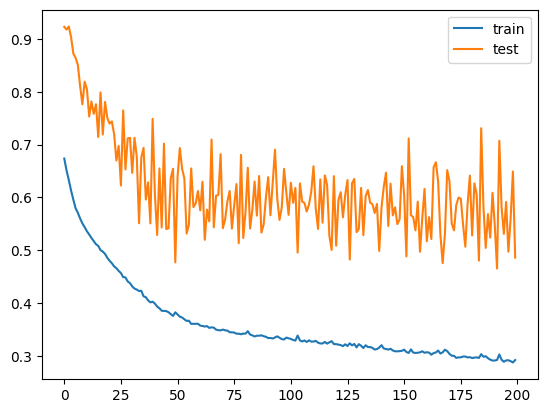

32/32 [==============================] - 0s 1ms/step
TRAIN undersampled
[[503  53]
 [ 81 475]]
              precision    recall  f1-score   support

    churn=NO       0.86      0.90      0.88       556
   churn=YES       0.90      0.85      0.88       556

    accuracy                           0.88      1112
   macro avg       0.88      0.88      0.88      1112
weighted avg       0.88      0.88      0.88      1112

TEST undersampled
[[745 104]
 [ 23 128]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.88      0.92       849
   churn=YES       0.55      0.85      0.67       151

    accuracy                           0.87      1000
   macro avg       0.76      0.86      0.79      1000
weighted avg       0.91      0.87      0.88      1000

smote
Epoch 1/200
87/87 [==============================] - 2s 10ms/step - loss: 0.6349 - accuracy: 0.6327 - calculate_f1_score: 0.0694 - calculate_precision: 0.4943 - calculate_recall: 0.0390 - val_loss: 0.7681

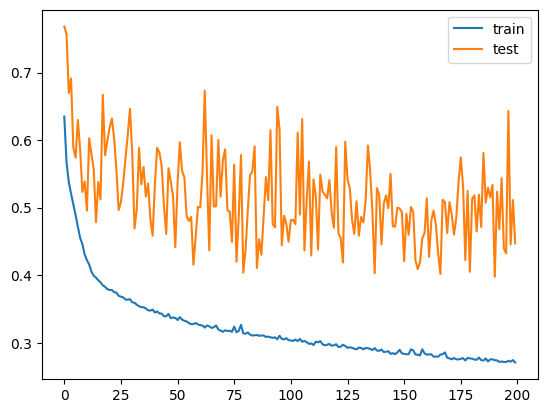

32/32 [==============================] - 0s 1ms/step
TRAIN smote
[[3301  142]
 [ 794 2649]]
              precision    recall  f1-score   support

    churn=NO       0.81      0.96      0.88      3443
   churn=YES       0.95      0.77      0.85      3443

    accuracy                           0.86      6886
   macro avg       0.88      0.86      0.86      6886
weighted avg       0.88      0.86      0.86      6886

TEST smote
[[806  43]
 [ 32 119]]
              precision    recall  f1-score   support

    churn=NO       0.96      0.95      0.96       849
   churn=YES       0.73      0.79      0.76       151

    accuracy                           0.93      1000
   macro avg       0.85      0.87      0.86      1000
weighted avg       0.93      0.93      0.93      1000

oversample
Epoch 1/200
87/87 [==============================] - 2s 7ms/step - loss: 0.6356 - accuracy: 0.6429 - calculate_f1_score: 0.0841 - calculate_precision: 0.4943 - calculate_recall: 0.0467 - val_loss: 0.8946 - val

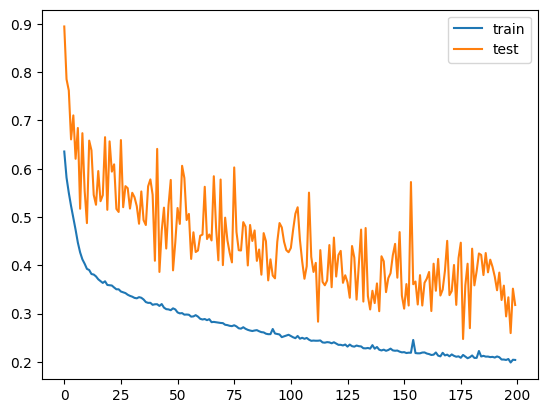

32/32 [==============================] - 0s 1ms/step
TRAIN oversample
[[3332  111]
 [ 553 2890]]
              precision    recall  f1-score   support

    churn=NO       0.86      0.97      0.91      3443
   churn=YES       0.96      0.84      0.90      3443

    accuracy                           0.90      6886
   macro avg       0.91      0.90      0.90      6886
weighted avg       0.91      0.90      0.90      6886

TEST oversample
[[817  32]
 [ 36 115]]
              precision    recall  f1-score   support

    churn=NO       0.96      0.96      0.96       849
   churn=YES       0.78      0.76      0.77       151

    accuracy                           0.93      1000
   macro avg       0.87      0.86      0.87      1000
weighted avg       0.93      0.93      0.93      1000

unbalance
Epoch 1/200
50/50 [==============================] - 2s 10ms/step - loss: 0.4638 - accuracy: 0.8612 - calculate_f1_score: 0.0000e+00 - calculate_precision: 0.0000e+00 - calculate_recall: 0.0000e+00 - 

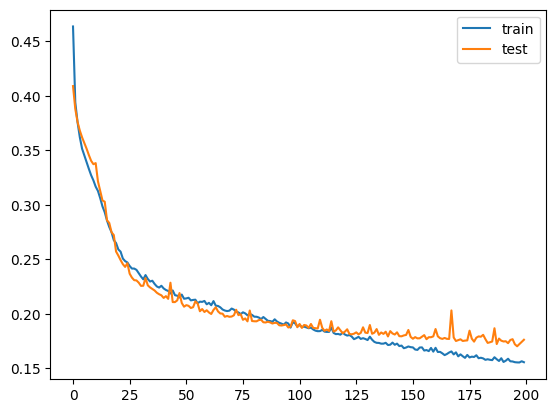

32/32 [==============================] - 0s 2ms/step
TRAIN unbalance
[[3377   66]
 [ 141  415]]
              precision    recall  f1-score   support

    churn=NO       0.96      0.98      0.97      3443
   churn=YES       0.86      0.75      0.80       556

    accuracy                           0.95      3999
   macro avg       0.91      0.86      0.89      3999
weighted avg       0.95      0.95      0.95      3999

TEST unbalance
[[833  16]
 [ 37 114]]
              precision    recall  f1-score   support

    churn=NO       0.96      0.98      0.97       849
   churn=YES       0.88      0.75      0.81       151

    accuracy                           0.95      1000
   macro avg       0.92      0.87      0.89      1000
weighted avg       0.95      0.95      0.95      1000



In [ ]:
def calculate_recall(y_true, y_pred):
    y_true = K.ones_like(y_true)
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    all_positives = K.sum(K.round(K.clip(y_true, 0, 1)))

    recall = true_positives / (all_positives + K.epsilon())
    return recall

def calculate_precision(y_true, y_pred):
    y_true = K.ones_like(y_true)
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))

    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    local_precision = true_positives / (predicted_positives + K.epsilon())
    return local_precision

def calculate_f1_score(y_true, y_pred):
    precision = calculate_precision(y_true, y_pred)
    recall = calculate_recall(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

scaler = MinMaxScaler()

for dataset in dict_train_samplers.keys():

  print(dataset)

  # Scale the data
  X_train_scaled = scaler.fit_transform(dict_train_samplers[dataset]['x'])
  X_test_scaled = scaler.transform(X_ts)

  # define model
  model = Sequential()
  model.add(Dense(50, input_dim=8, activation='relu'))
  model.add(Dense(50,  activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', calculate_f1_score, calculate_precision, calculate_recall])

  # fit model

  history = model.fit(X_train_scaled,dict_train_samplers[dataset]['y'],validation_split=0.2,batch_size=64,epochs=200, verbose=1)

  # Evaluate the model on training and test sets

  result_train = model.evaluate(X_train_scaled, dict_train_samplers[dataset]['y'], verbose=1)
  result_test = model.evaluate(X_test_scaled, y_ts, verbose=2)

  print('Train:', result_train)
  print('Test:', result_test)

  # plot training history
  plt.plot(history.history['loss'], label='train')
  plt.plot(history.history['val_loss'], label='test')
  plt.legend()
  plt.show()

  # Predict probabilities for train and test sets
  y_train_pred_prob = model.predict(X_train_scaled)
  y_test_pred_prob = model.predict(X_test_scaled)

  # Convert probabilities to binary predictions based on a threshold (0.5 for example)
  threshold = 0.5
  y_train_pred = np.where(y_train_pred_prob > threshold, 1, 0)
  y_test_pred = np.where(y_test_pred_prob > threshold, 1, 0)

  model_evaluation(dict_train_samplers[dataset]['y'],y_train_pred,text='TRAIN '+str(dataset),save=True,model='NN')
  model_evaluation(y_ts,y_test_pred,text='TEST '+str(dataset),save=True,model='NN')


In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('RNN'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score


The best RNN architecture consists of two hidden layers, the first with 50 neurons and the second with 10 neurons. Reducing the number of neurons tends to produce underfitting and adding new layers reveals overfitting. The same happens when considerably increasing the number of neurons.

The RNN model is not very sensitive to data unbalance. 'UNBALENCED' datasets produces the best results. Using the 'UNDERSAMPLED' dataset shows overfitting with a lower model complexity.

The best RNN model (two hidden layers with 50 and 10 neurons each) with the'UNBALENCED' dataset is correct in 90% of the times for the YES label (9 out of 10) and detects 68% of the actual YES label (almost 7 out of 10).

## Logistic regression

The logistic regression model uses 'Randomized Search' with a fixed k-folds value of 10 and a range of 0.0001 to 10000 for the parameter C.The hyperparameter were fine-tune for the four datasets using different sampling techniques. The UNBALANCED dataset presented the highest C value and the UNDERSAMPLED the C lowest value, as expected. In terms of scoring metrics, the "F1-Score weighted" score was employed for all datasets except the "unbalanced" one, which utilized the "F1-Score macro" for evaluation.

In [ ]:
# Define the parameter distribution

param_distLG =[{'C': loguniform(0.0001, 10000),
                 "random_state": [42]
                 }]

dict_hyperparameters_lg={'undersampled':{'C':0.23,'random_state': 42},
                      'smote':{'C':1.17,'random_state': 42},
                      'oversample':{'C':1.17,'random_state': 42},
                      'unbalance':{'C':29.77,'random_state': 42}}

scaler = MinMaxScaler()

# Instantiate the grid

for dataset in dict_train_samplers.keys():

  print(dataset)

  if dataset=='unbalance':
    score_metric='f1_macro'
  else:
    score_metric='f1_weighted'

  if grid_search:

    lg_clf = RandomizedSearchCV(estimator=LogisticRegression(),
                                param_distributions=param_distLG,
                                cv=10,
                                n_iter=20,
                                scoring=score_metric,
                                verbose=1,random_state=42)

  else:

    lg_clf=LogisticRegression(C=dict_hyperparameters_lg[dataset]['C'],random_state=dict_hyperparameters_lg[dataset]['random_state'])

  # Scale the data
  X_train_scaled = scaler.fit_transform(dict_train_samplers[dataset]['x'])
  X_test_scaled = scaler.transform(X_ts)

  # Model train
  lg_clf.fit(X_train_scaled, dict_train_samplers[dataset]['y'])

  if grid_search==True:
      print("Best parameters:", lg_clf.best_params_)
      print("better accuracy: ", (lg_clf.best_score_)**(1/2.0))

  # Previsões usando o conjunto de treino
  y_tr_pred = lg_clf.predict(X_train_scaled)
  model_evaluation(dict_train_samplers[dataset]['y'],y_tr_pred,text='TRAIN '+str(dataset),save=True,model='LG')

  # Prever usando o conjunto de teste
  y_ts_pred = lg_clf.predict(X_test_scaled)
  model_evaluation(y_ts,y_ts_pred,text='TEST '+str(dataset),save=True,model='LG')


undersampled
TRAIN undersampled
[[425 131]
 [140 416]]
              precision    recall  f1-score   support

    churn=NO       0.75      0.76      0.76       556
   churn=YES       0.76      0.75      0.75       556

    accuracy                           0.76      1112
   macro avg       0.76      0.76      0.76      1112
weighted avg       0.76      0.76      0.76      1112

TEST undersampled
[[682 167]
 [ 30 121]]
              precision    recall  f1-score   support

    churn=NO       0.96      0.80      0.87       849
   churn=YES       0.42      0.80      0.55       151

    accuracy                           0.80      1000
   macro avg       0.69      0.80      0.71      1000
weighted avg       0.88      0.80      0.83      1000

smote
TRAIN smote
[[2532  911]
 [ 679 2764]]
              precision    recall  f1-score   support

    churn=NO       0.79      0.74      0.76      3443
   churn=YES       0.75      0.80      0.78      3443

    accuracy                           0.

In [ ]:
df_result[(df_result["Text"].str.startswith('TEST'))&(df_result["Model"].str.startswith('LG'))][["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]]

,Model,Text,Accuracy,Precision,Recall,F1-score
57,LG,TEST undersampled,0.803,42.01%,80.13%,55.13%
59,LG,TEST smote,0.755,35.49%,76.16%,48.42%
61,LG,TEST oversample,0.790,40.33%,81.46%,53.95%
63,LG,TEST unbalance,0.862,62.75%,21.19%,31.68%


The "UNDERSAMPLED" dataset presented the highest "F1-Score" for the churn "YES" label (55%). The model is correct only in 42% of the time for the "YES" label (1 out of 3), low precision for the "YES" label. Nevertheless, it detects 80% of the actual "YES" label (8 out of 10). It has a high sensitivity but a low precision for the "YES" label. ​

## Ensamble

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

for dataset in dict_train_samplers.keys():
  print(dataset)
  x_sample = dict_train_samplers[dataset]['x']
  y_sample = dict_train_samplers[dataset]['y']
  estimators = []
  #estimators.append(('KNN', KNeighborsClassifier(n_neighbors=dict_hyperparameters_knn[dataset]['n'])))
  estimators.append(('Decision Tree Classifier', DecisionTreeClassifier(max_depth=DTdict_hyperparameters[dataset]['max_depth'],random_state=42)))
  estimators.append(('RandomForest', RandomForestClassifier(n_estimators=dict_hyperparameters_rf[dataset]['n_estimators'],max_depth=dict_hyperparameters_rf[dataset]['max_depth'],random_state=42)))
  estimators.append(('SVM', SVC(C=dict_hyperparameters_svm[dataset]['C'],kernel=dict_hyperparameters_svm[dataset]['kernel'],gamma=dict_hyperparameters_svm[dataset]['gamma'], probability=True,random_state=42)))
  estimators.append(('LogisticRegression', SVC(C=dict_hyperparameters_lg[dataset]['C'],random_state=dict_hyperparameters_lg[dataset]['random_state'])))
  #estimators.append(('MLPClassifier', MLPClassifier(max_iter=2000,random_state=13) ))


  #HARD
  ensemble_hard = VotingClassifier(
      estimators=estimators,
      voting='hard'
  )
  print('voting hard')
  ensemble_hard.fit(x_sample, y_sample)
  y_tr_pred_hard = ensemble_hard.predict(x_sample)
  cross_validation = cross_val_score(ensemble_hard, x_sample, y_sample, cv=10, scoring='f1')
  print(f'Avg Score cross-validation -> {np.mean(cross_validation)}')
  y_ts_pred_hard = ensemble_hard.predict(X_ts)
  model_evaluation(dict_train_samplers[dataset]['y'],y_tr_pred_hard,text='TRAIN '+str(dataset),save=True,model='Voting_hard')
  model_evaluation(y_ts,y_ts_pred_hard,text='TEST '+str(dataset),save=True,model='Voting_hard')


undersampled
voting hard
Avg Score cross-validation -> 0.7060083338209336
TRAIN undersampled
[[556   0]
 [ 70 486]]
              precision    recall  f1-score   support

    churn=NO       0.89      1.00      0.94       556
   churn=YES       1.00      0.87      0.93       556

    accuracy                           0.94      1112
   macro avg       0.94      0.94      0.94      1112
weighted avg       0.94      0.94      0.94      1112

TEST undersampled
[[810  39]
 [ 54  97]]
              precision    recall  f1-score   support

    churn=NO       0.94      0.95      0.95       849
   churn=YES       0.71      0.64      0.68       151

    accuracy                           0.91      1000
   macro avg       0.83      0.80      0.81      1000
weighted avg       0.90      0.91      0.90      1000

smote
voting hard
Avg Score cross-validation -> 0.8610595369068141
TRAIN smote
[[3423   20]
 [ 559 2884]]
              precision    recall  f1-score   support

    churn=NO       0.86     

In [ ]:

for dataset in dict_train_samplers.keys():
    print(dataset)
    x_sample = dict_train_samplers[dataset]['x']
    y_sample = dict_train_samplers[dataset]['y']

    nb= model_nb_gau = GaussianNB().fit(x_sample, y_sample)
    knn = KNeighborsClassifier(n_neighbors=dict_hyperparameters_knn[dataset]['n'])
    ddt = DecisionTreeClassifier(max_depth=DTdict_hyperparameters[dataset]['max_depth'], random_state=42)
    rd = RandomForestClassifier(n_estimators=dict_hyperparameters_rf[dataset]['n_estimators'],
                                max_depth=dict_hyperparameters_rf[dataset]['max_depth'], random_state=42)
    svc = SVC(C=dict_hyperparameters_svm[dataset]['C'], kernel=dict_hyperparameters_svm[dataset]['kernel'],
              gamma=dict_hyperparameters_svm[dataset]['gamma'], probability=True, random_state=42)

    nb.fit(x_sample, y_sample)
    knn.fit(x_sample, y_sample)
    ddt.fit(x_sample, y_sample)
    svc.fit(x_sample, y_sample)
    rd.fit(x_sample, y_sample)

    tr_pred1 = nb.predict_proba(x_sample)
    tr_pred2 = knn.predict_proba(x_sample)
    tr_pred3 = ddt.predict_proba(x_sample)
    tr_pred4 = rd.predict_proba(x_sample)
    tr_pred5 = svc.predict_proba(x_sample)
    tr_finalpred = (tr_pred1 + tr_pred2 + tr_pred3 + tr_pred4 + tr_pred5) / 5


    tr_multiclass_pred = np.argmax(tr_finalpred, axis=1)

    ts_pred1 = nb.predict_proba(X_ts)
    ts_pred2 = knn.predict_proba(X_ts)
    ts_pred3 = ddt.predict_proba(X_ts)
    ts_pred4 = rd.predict_proba(X_ts)
    ts_pred5 = svc.predict_proba(X_ts)

    ts_finalpred = (ts_pred1 + ts_pred2 + ts_pred3 + ts_pred4 + ts_pred5) / 5
    ts_multiclass_pred = np.argmax(ts_finalpred, axis=1)

    model_evaluation(dict_train_samplers[dataset]['y'], tr_multiclass_pred, text='TRAIN '+str(dataset), save=True,
                     model='averaging')
    model_evaluation(y_ts, ts_multiclass_pred, text='TEST '+str(dataset), save=True, model='averaging')

undersampled
TRAIN undersampled
[[535  21]
 [ 67 489]]
              precision    recall  f1-score   support

    churn=NO       0.89      0.96      0.92       556
   churn=YES       0.96      0.88      0.92       556

    accuracy                           0.92      1112
   macro avg       0.92      0.92      0.92      1112
weighted avg       0.92      0.92      0.92      1112

TEST undersampled
[[774  75]
 [ 23 128]]
              precision    recall  f1-score   support

    churn=NO       0.97      0.91      0.94       849
   churn=YES       0.63      0.85      0.72       151

    accuracy                           0.90      1000
   macro avg       0.80      0.88      0.83      1000
weighted avg       0.92      0.90      0.91      1000

smote
TRAIN smote
[[3426   17]
 [  24 3419]]
              precision    recall  f1-score   support

    churn=NO       0.99      1.00      0.99      3443
   churn=YES       1.00      0.99      0.99      3443

    accuracy                           0.

Between the Voting Ensemble and averaging Ensemble, results showed us that the Averaging of the 5 different predictions got better results. In this Ensemble 'F1-Scores' were significantly high, the highest being the "OVERSAMPLE" with 75%. With most datasets having similar values except the "UNBALANCED" dataset that had a low recall.

The Ensembling of different models through averaging and Voting(Hard) gave us information but did not result in a better model since individual models like RNN or DT gave us better scores.  

## Comparison

In [ ]:
df_result[["Model", "Text", "Accuracy", "Precision", "Recall", "F1-score"]][df_result["Text"].str.startswith('TEST')].sort_values(by=['F1-score'], ascending=False)

,Model,Text,Accuracy,Precision,Recall,F1-score
55,NN,TEST unbalance,0.947,87.69%,75.50%,81.14%
53,NN,TEST oversample,0.932,78.23%,76.16%,77.18%
31,DT,TEST unbalance,0.938,88.70%,67.55%,76.69%
51,NN,TEST smote,0.925,73.46%,78.81%,76.04%
77,averaging,TEST oversample,0.932,84.30%,67.55%,75.00%
37,RF,TEST oversample,0.922,73.25%,76.16%,74.68%
39,RF,TEST unbalance,0.938,97.85%,60.26%,74.59%
29,DT,TEST oversample,0.918,72.55%,73.51%,73.03%
35,RF,TEST smote,0.917,72.08%,73.51%,72.79%
73,averaging,TEST undersampled,0.902,63.05%,84.77%,72.32%


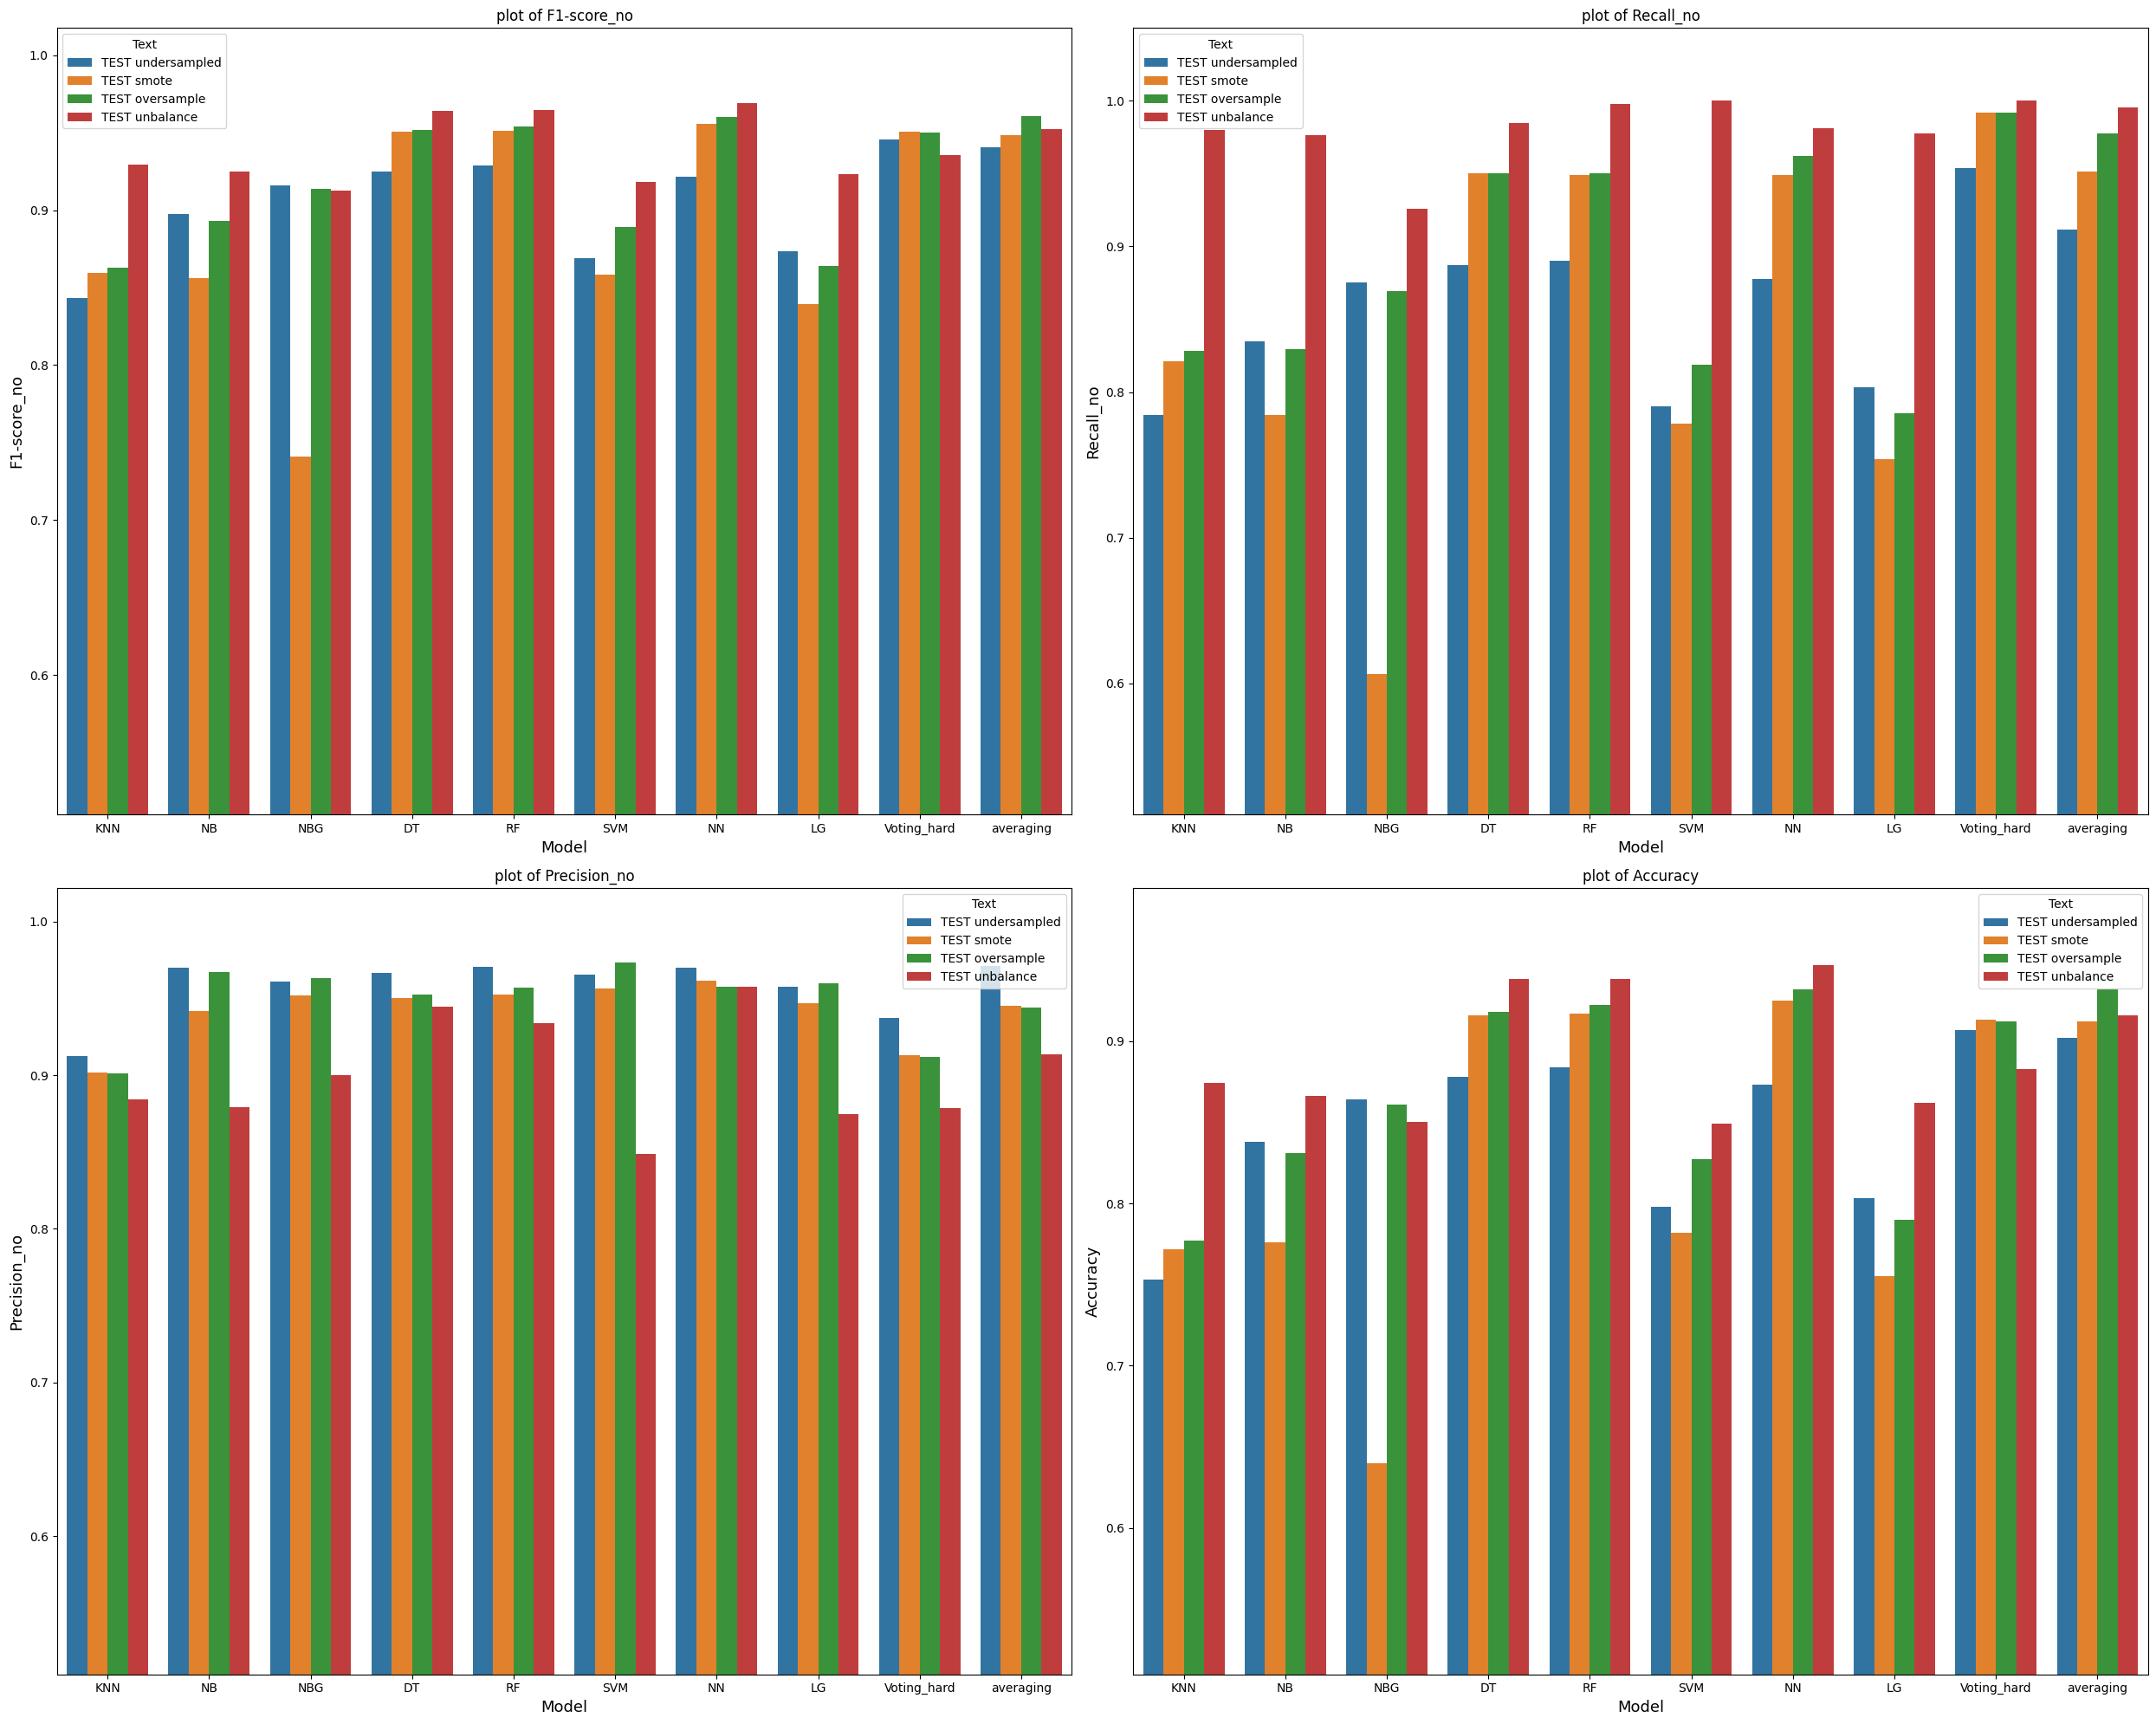

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(25, 20))
scores_types = {'F1-score_no': [0, 0], 'Recall_no': [0, 1],'Precision_no': [1, 0], 'Accuracy': [1, 1]}

for scor in  scores_types:
  index = scores_types[scor][1]
  row = scores_types[scor][0]
  sns.barplot(x='Model', y=scor, hue='Text', data=df_result[df_result["Text"].str.startswith('TEST')], ax=axes[row, index])
  axes[row, index].set_ylim(0.51, None)
  axes[row, index].set_xlabel('Model', fontsize=13)
  axes[row, index].set_ylabel(scor, fontsize=13)
  axes[row, index].set_title(f'plot of {scor}')
plt.tight_layout()
plt.show()

From the plots above, we can it was easy to have high scores regarding 'CHURN=NO' in all models

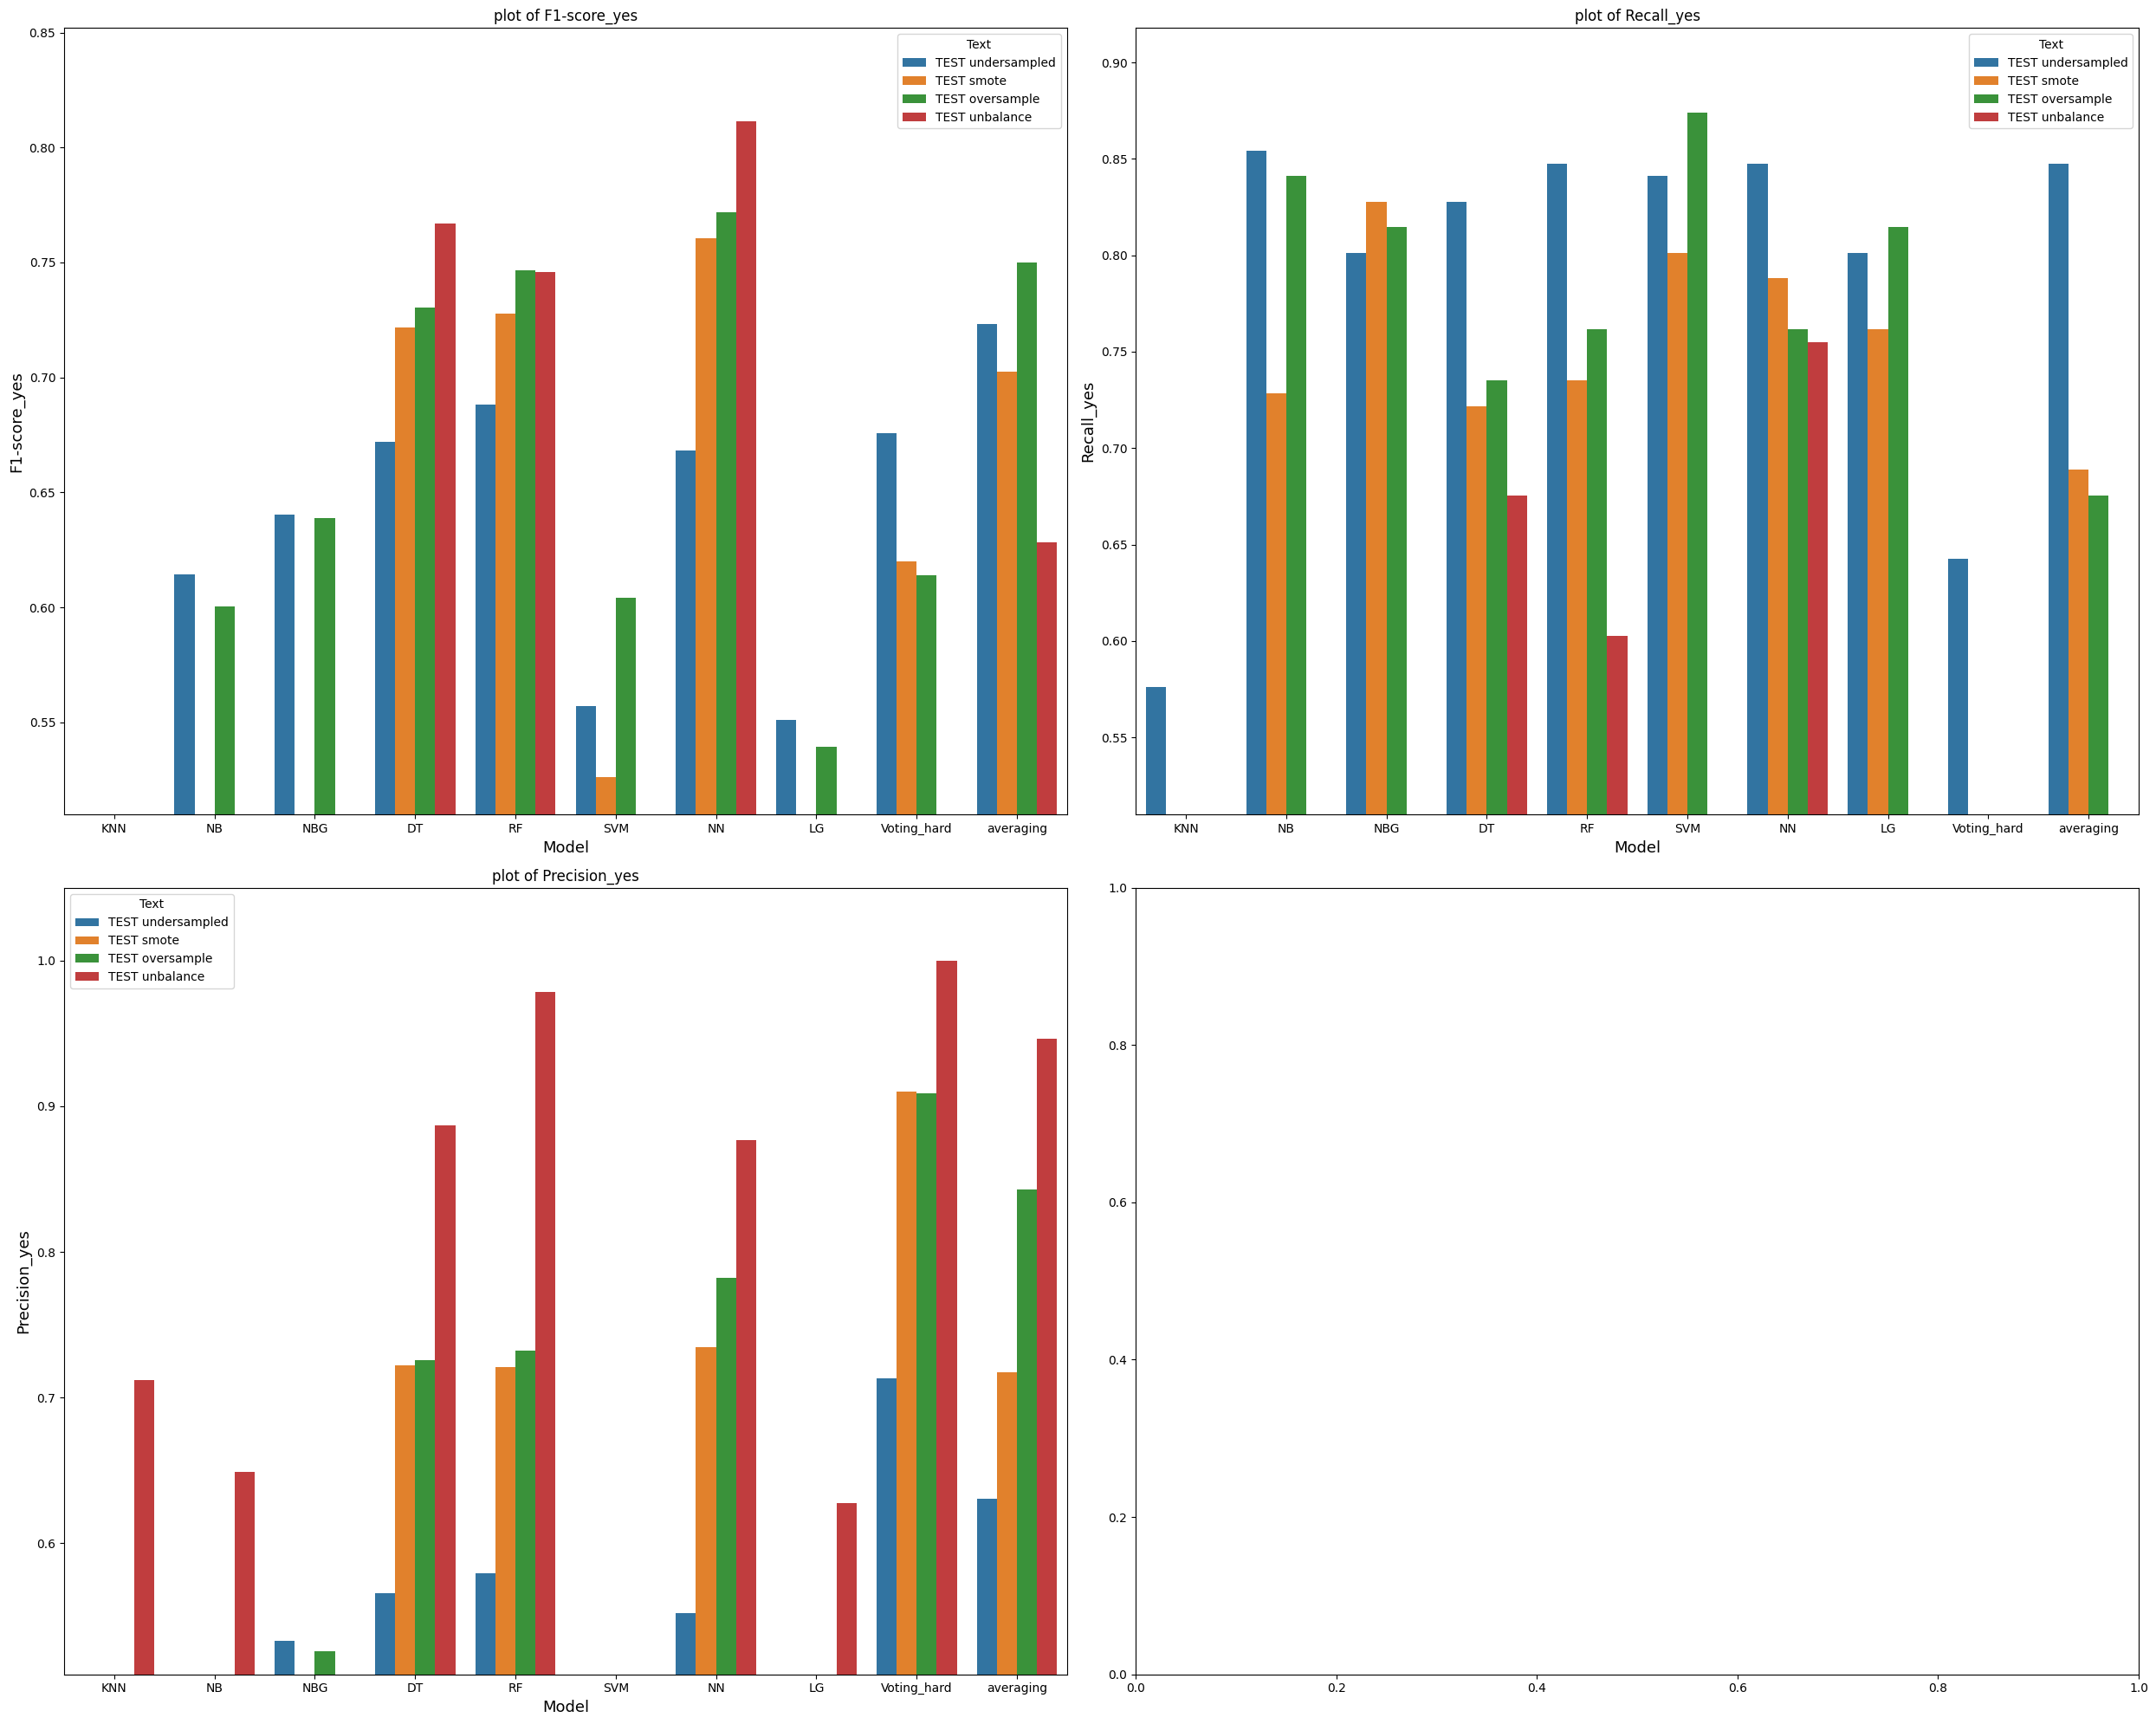

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(25, 20))
scores_types = {'F1-score_yes': [0, 0], 'Recall_yes': [0, 1], 'Precision_yes': [1, 0]}

for scor in  scores_types:
  index = scores_types[scor][1]
  row = scores_types[scor][0]
  sns.barplot(x='Model', y=scor, hue='Text', data=df_result[df_result["Text"].str.startswith('TEST')], ax=axes[row, index])
  axes[row, index].set_ylim(0.51, None)
  axes[row, index].set_xlabel('Model', fontsize=13)
  axes[row, index].set_ylabel(scor, fontsize=13)
  axes[row, index].set_title(f'plot of {scor}')
plt.tight_layout()
plt.show()

By looking at the F1-Score regarding 'CHURN=YES' we can see that values for the test models above 0.65 were rare. Only 3 models(Decision Tree, Random Forest Classifier and Neural Networks) were consistently better than the others. The 3 models present scores higher than 65% indipendently of the dataset. For F1-Score(CHURN=YES), the  NN ('OVERSAMPLE') model was the highest with the DT and RF close behind, also for the 'UNBALANCED' dataset.

The Recall_yes plot showed that the sampling was important to increase the models sensitivity by looking at the low values in the 'UNBALANCED' dataset(only NN, DT and RF having scores above 0.51). The samplisng techinque allowed that almost all models presented good Recall scores.

The 'UNBALANCED' dataset had the most precise results for most models (except NBG), leading to high F1 scores for NN, DT and DT (only these models presented good Recall values for the UNBALANCED dataset).

The NN, DT and RF presented the best overall results due to the superior Precision scores obtained for all datasets, especialy compared with the other models, combined with good Recall scores.This was aprticulary important for the UNBALANCED dataset.



# Conclusions

In conclusion, the models showed a higher ability to predict CHURN=YES than expected considering the high homogeneity of the dataset (the data understanding showed small differences in few instances). Depending on the cost of leaving customers not being identified two models can be selected:
In terms of interpretability through visualization plots, and if we prioritize the reduce of customers with special attention (high precision) we are of the opinion that the superior model for the business would be the 'Decision Tree'. The balance techniques in this algorithm guaranteed higher recall scores which from a business perspective is very interesting.
If we prioritize identifying the higher possible percentage of leaving customers (high sensitivity) the Neural Network (high recall) are the most useful. Moreover, the previous algorithm is not very sensitive to unbalanced data.
Based on the existing data, algorithms do not perform identically, and their development was crucial. Nevertheless, obtaining a higher quantity and quality of training data will likely lead the algorithms to perform more similarly. Therefore, it is important to collect new features and gather more data.



